# Init

In [1]:
import pandas as pd
from itables import show
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
model_list = ['Base_SASRec', 'w2v','bert', 'gemini', 'openai', 'qwen']
# model_list = ['Base_SASRec', 'w2v', 'bert', 'minilm', 'e5', 'bge', 'gemini', 'openai', 'harrier', 'qwen']

# data

In [3]:
df_master = pd.read_csv('public_results/evaluation_metrics_l_2_h_1_hd_1024_trainable_True_lr_0.0001.csv')

In [4]:
mask = df_master['Model'].isin(model_list)
df_master = df_master[mask]
df_master['Model'].value_counts()

Model
w2v            180
bert           180
openai         180
gemini         180
qwen           180
Base_SASRec     36
Name: count, dtype: int64

In [5]:
df_master_all_users = df_master[(df_master['User_Type'] == 'all')].copy()
df_master_all_users

,User_Type,Weight_Profile,Model,k,HitRate,NDCG,unSerendipity,Train_Scenario,trainable
0,all,NaN,Base_SASRec,2,0.020537,0.017622,0.118138,1.0,True
1,all,NaN,Base_SASRec,4,0.028436,0.021133,0.116483,1.0,True
2,all,NaN,Base_SASRec,6,0.039494,0.025314,0.115021,1.0,True
3,all,NaN,Base_SASRec,8,0.050553,0.028888,0.112963,1.0,True
4,all,NaN,Base_SASRec,10,0.055292,0.030314,0.111261,1.0,True
...,...,...,...,...,...,...,...,...,...
787,all,weight_4,qwen,16,0.001580,0.000790,0.152257,3.0,True
788,all,weight_4,qwen,18,0.003160,0.001169,0.154443,3.0,True
789,all,weight_4,qwen,20,0.003160,0.001169,0.156437,3.0,True
790,all,weight_4,qwen,30,0.004739,0.001497,0.164614,3.0,True


# plot_single_model_metrics

In [6]:
def plot_single_model_metrics(df, model_name, user_type='all', weight_profile='None', train_scenario='1', title="Performa Metrik terhadap K"):
    model_mask = df['Model'].astype(str).str.strip() == model_name
    user_mask = df['User_Type'].astype(str).str.strip() == user_type
    weight_mask = df['Weight_Profile'].fillna('None').astype(str).str.strip() == weight_profile
    scenario_mask = pd.to_numeric(df['Train_Scenario'], errors='coerce') == float(train_scenario)
    
    # Terapkan semua filter
    df_model = df[model_mask & user_mask & weight_mask & scenario_mask].copy()
    
    if df_model.empty:
        print(f"Data tidak ditemukan untuk Model: {model_name}, User: {user_type}, Weight: {weight_profile}, Scenario: {train_scenario}")
        return
        
    df_melt = df_model.melt(
        id_vars=['k'],
        value_vars=['HitRate', 'NDCG', 'unSerendipity'],
        var_name='Metrik', 
        value_name='Skor'
    )
    
    plt.figure(figsize=(9, 5))
    sns.lineplot(
        data=df_melt, 
        x='k', y='Skor', 
        hue='Metrik', 
        style='Metrik', 
        markers=True, dashes=False, linewidth=2, markersize=8,
        palette=['#1f77b4', '#ff7f0e', '#2ca02c'] # Biru, Oranye, Hijau
    )
    
    full_title = f'{title} - {model_name}\n(User: {user_type} | Weight: {weight_profile} | Scenario: {train_scenario})'
    plt.title(full_title, fontsize=12, fontweight='bold')
    
    plt.xlabel('Top-K Recommendations (k)', fontsize=12)
    plt.ylabel('Skor', fontsize=12)
    plt.xticks(df_model['k'].unique())
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title="Metrik Evaluasi")
    plt.tight_layout()
    plt.show()

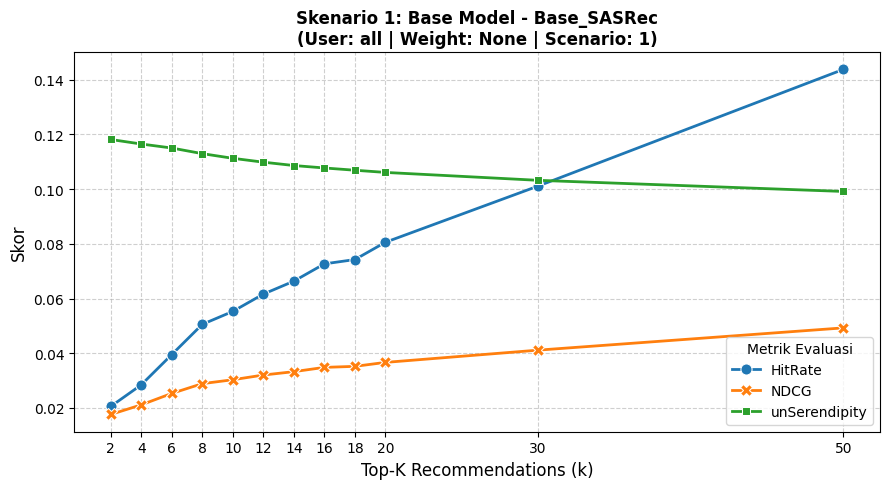

In [7]:
plot_single_model_metrics(df_master, model_name='Base_SASRec', title='Skenario 1: Base Model')

### scenario 2

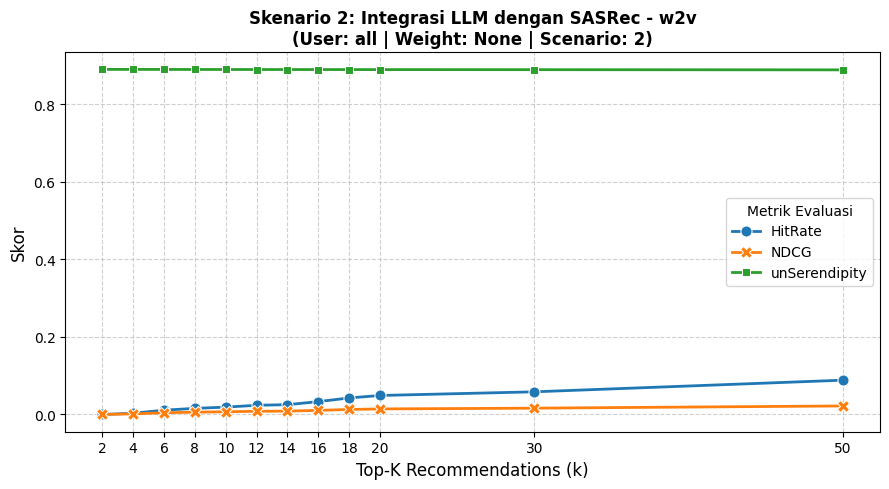

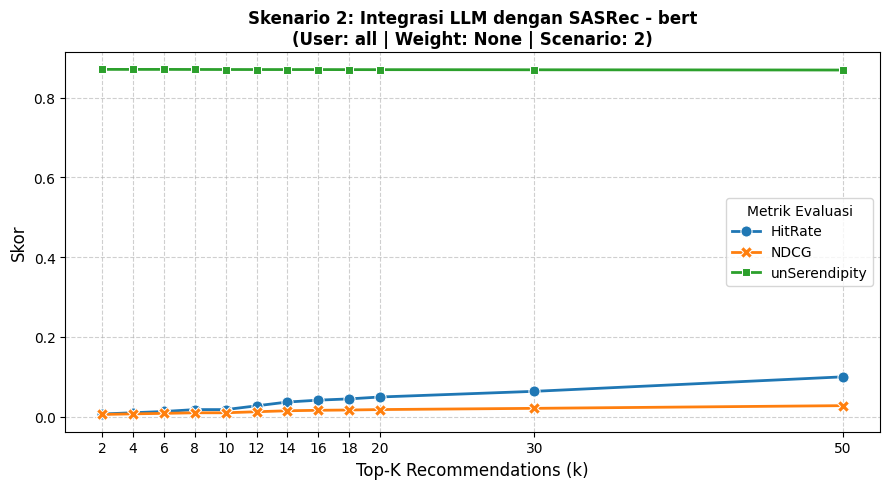

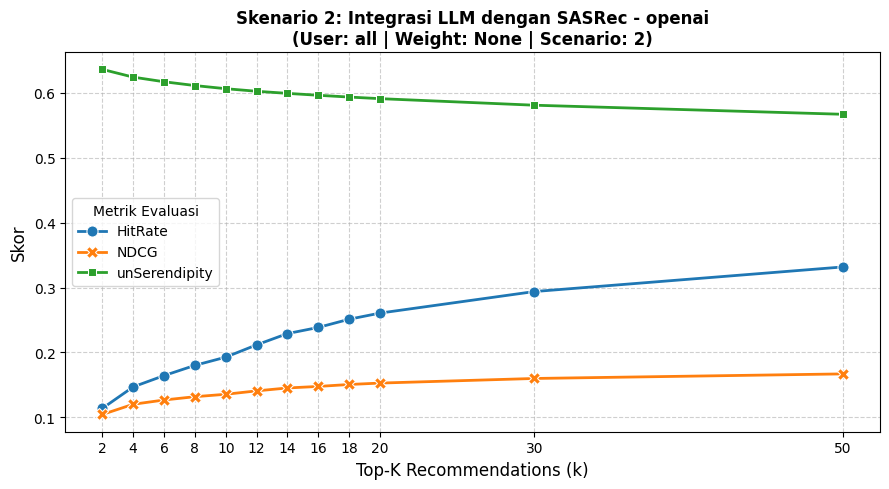

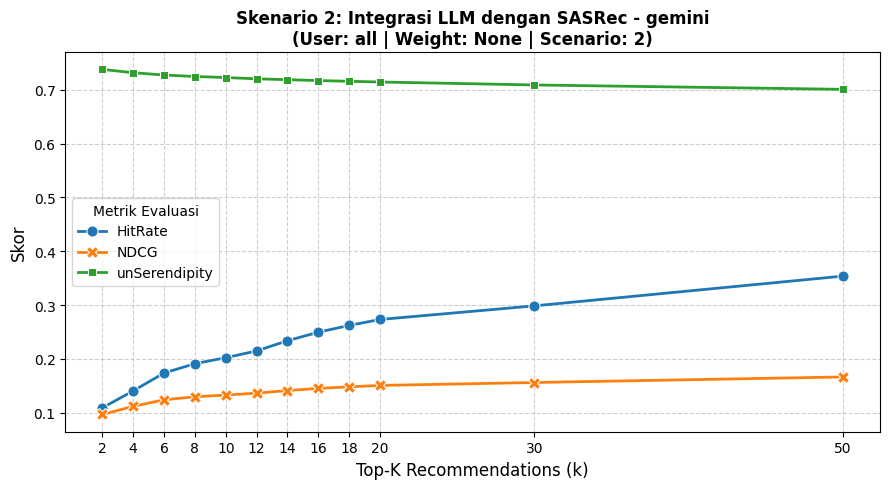

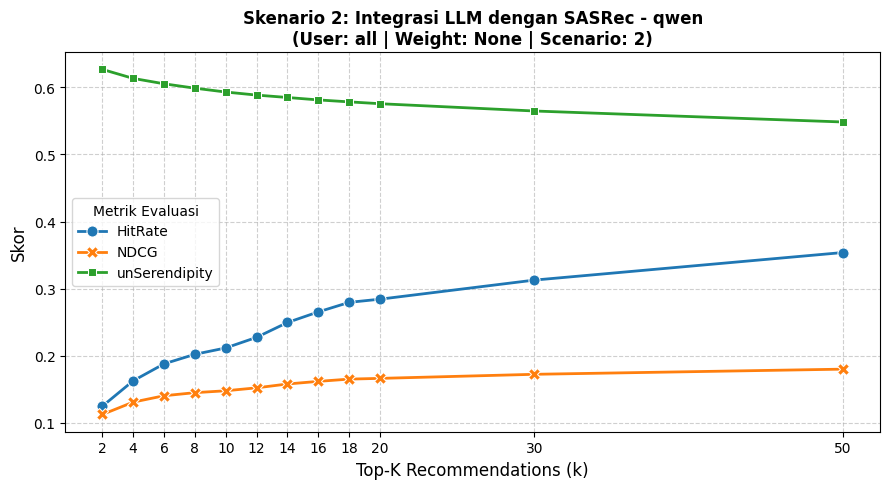

In [8]:
sasrecllm_models = [m for m in df_master_all_users['Model'].unique() if m != 'Base_SASRec']

for model_name in sasrecllm_models:
    plot_single_model_metrics(df_master_all_users, model_name=model_name, train_scenario='2', title='Skenario 2: Integrasi LLM dengan SASRec')

# plot_weight_comparison

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_weight_comparison(df, model_name, user_type='all', train_scenario=3):
    model_mask = df['Model'].astype(str).str.strip() == model_name
    user_mask = df['User_Type'].astype(str).str.strip() == user_type
    scenario_mask = pd.to_numeric(df['Train_Scenario'], errors='coerce') == float(train_scenario)
    
    df_filtered = df[model_mask & user_mask & scenario_mask].copy()
    
    df_filtered['Weight_Profile'] = df_filtered['Weight_Profile'].fillna('None')
    
    if df_filtered.empty:
        print(f"Data tidak ditemukan untuk Model: {model_name}, Skenario: {train_scenario}")
        return
        
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metrics = ['HitRate', 'NDCG', 'unSerendipity']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    for i, metric in enumerate(metrics):
        sns.lineplot(
            data=df_filtered,
            x='k',
            y=metric,
            hue='Weight_Profile',  # Membedakan warna berdasarkan weight
            style='Weight_Profile', # Membedakan bentuk garis/marker berdasarkan weight
            markers=True,
            dashes=False,
            linewidth=2,
            markersize=8,
            ax=axes[i],            # Menempatkan grafik di urutan yang tepat
            errorbar=None          # Mencegah bayangan jika ada duplikasi tak terduga
        )
        
        # Merapikan tampilan masing-masing subplot
        axes[i].set_title(f'{metric}', fontsize=14, fontweight='bold', color=colors[i])
        axes[i].set_xlabel('Top-K Recommendations (k)', fontsize=12)
        axes[i].set_ylabel('Skor', fontsize=12)
        axes[i].set_xticks(df_filtered['k'].unique())
        axes[i].grid(True, linestyle='--', alpha=0.6)
        
        # Pindahkan legend agar tidak menutupi garis
        axes[i].legend(title="Weight Profile")

    fig.suptitle(
        f'Pengaruh Weight Profile terhadap Metrik - Model: {model_name} (Skenario {train_scenario})', 
        fontsize=16, 
        fontweight='bold', 
        y=1.05
    )
    
    plt.tight_layout()
    plt.show()

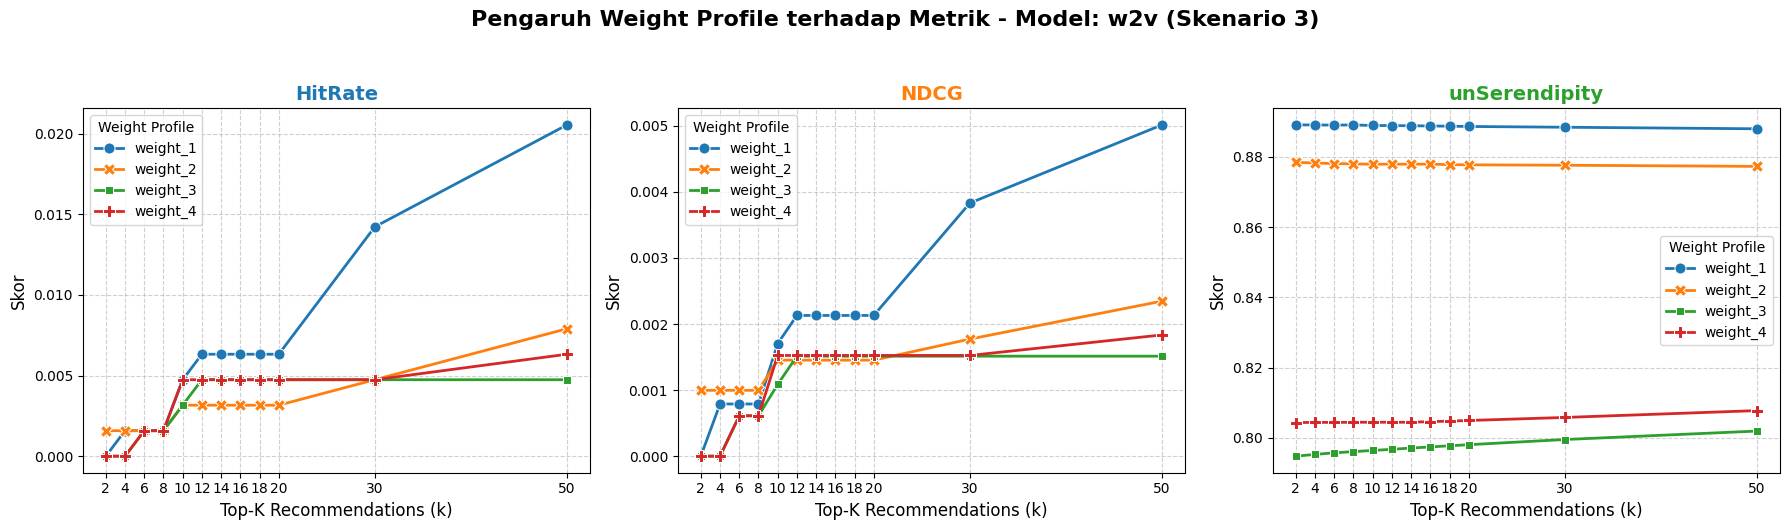

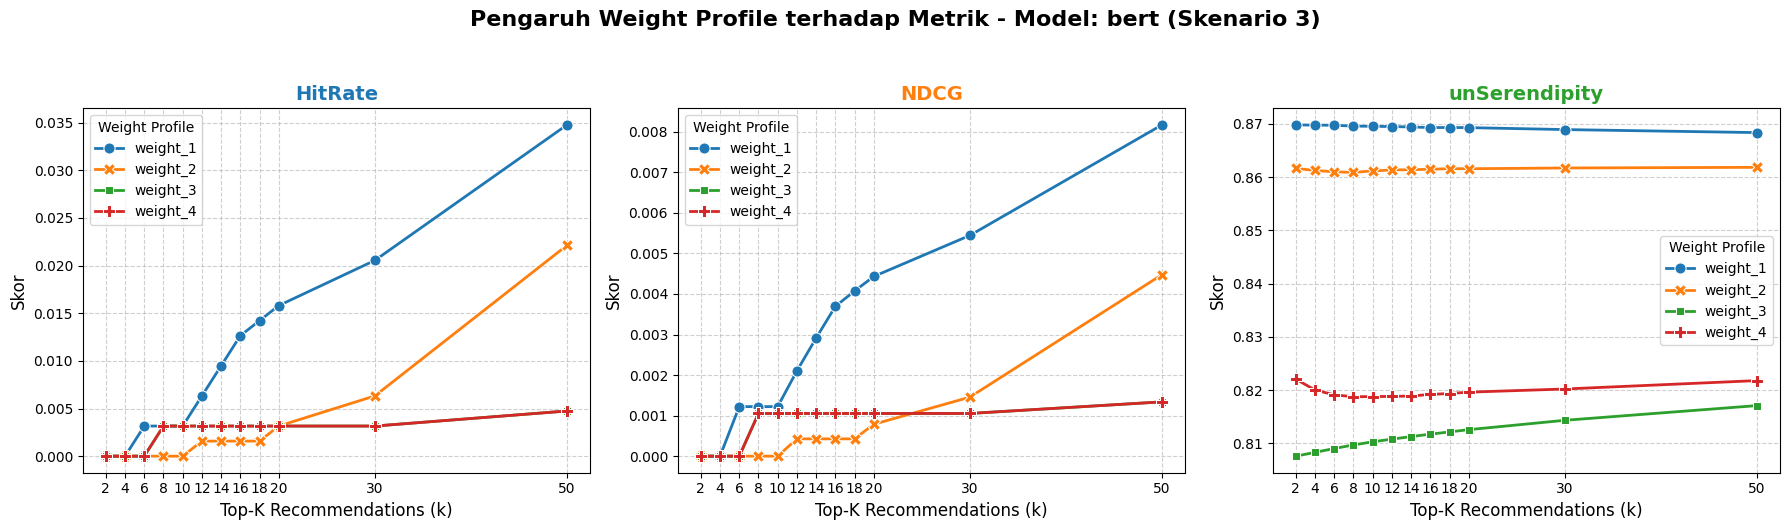

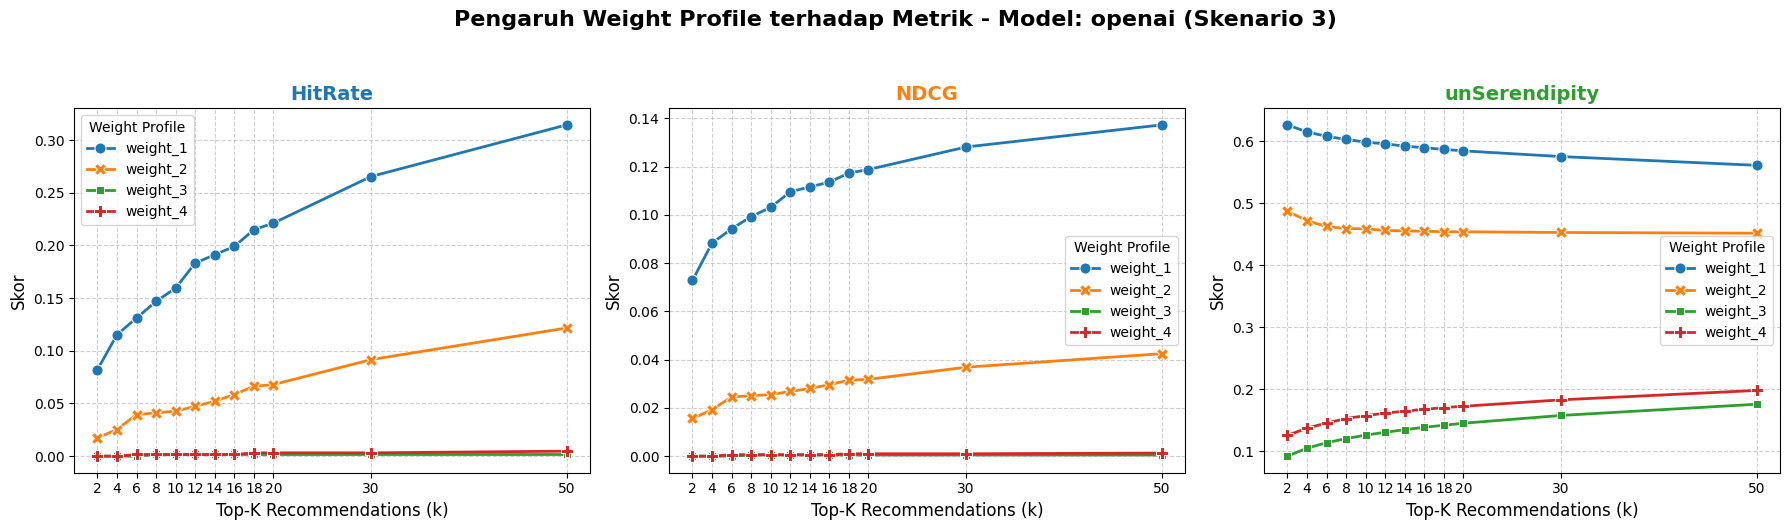

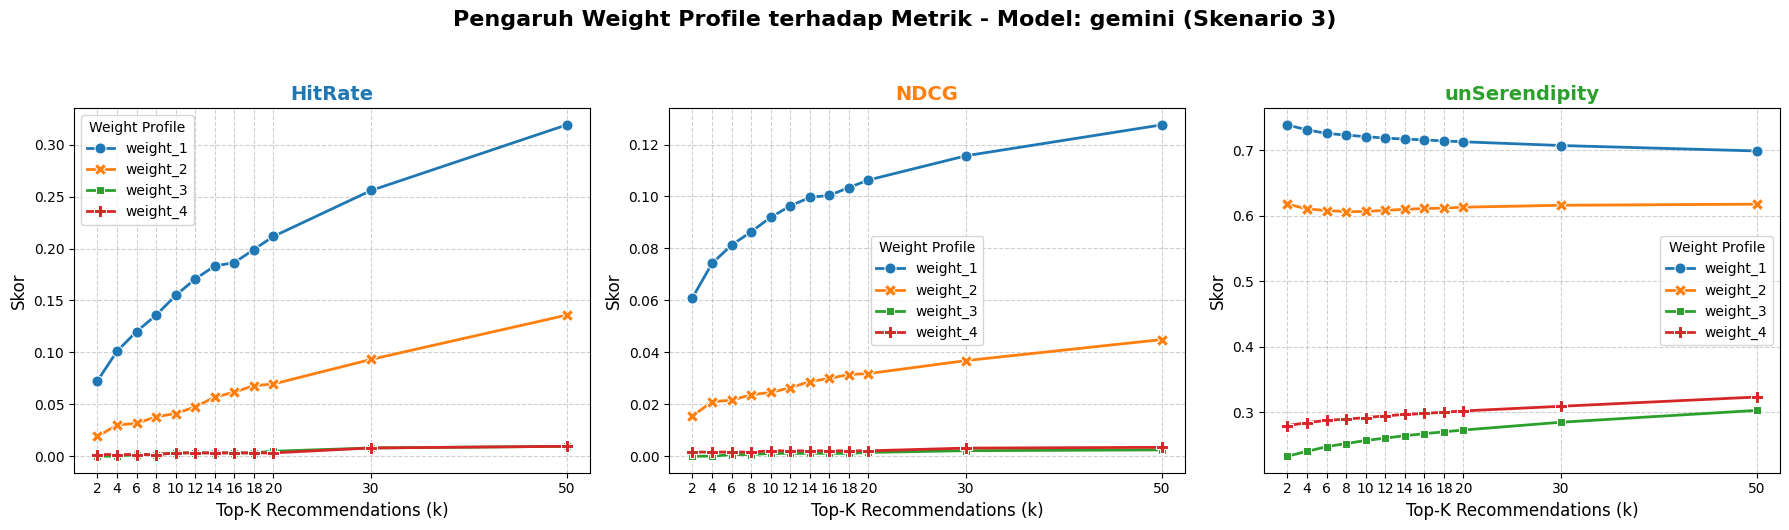

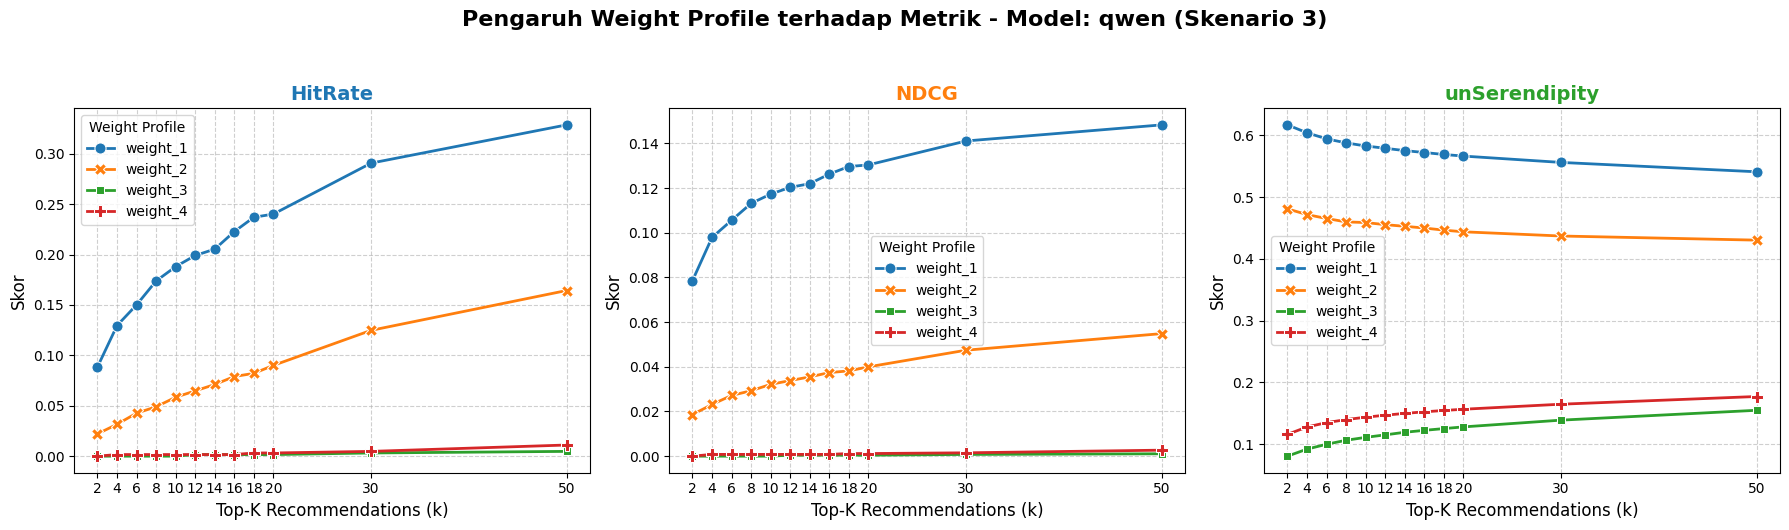

In [10]:
sog_models = [m for m in df_master_all_users['Model'].unique() if m != 'Base_SASRec']

for model_name in sog_models:
    plot_weight_comparison(df_master_all_users, model_name=model_name)

# plot_metric_competition

In [11]:
def plot_metric_competition(df, metric_to_plot, title, train_scenario=2, base_model='Base_SASRec', user_type='all'):
    df_filtered = df[
        (
            (df['Train_Scenario'] == train_scenario) | 
            (df['Model'] == base_model)
        ) &
        (df['User_Type'] == user_type)
    ].copy()

    if df_filtered.empty:
        print(f"Data kosong untuk Skenario {train_scenario} dan Base Model {base_model}")
        return
    
    plt.figure(figsize=(10, 6))
    
    sns.lineplot(
        data=df_filtered, 
        x='k', y=metric_to_plot, 
        hue='Model', 
        style='Model', 
        markers=True, dashes=False, linewidth=2, markersize=8
    )
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Top-K Recommendations (k)', fontsize=12)
    plt.ylabel(f'Skor {metric_to_plot}', fontsize=12)
    plt.xticks(df['k'].unique())
    
    # Pindahkan legenda ke luar grafik agar tidak menabrak garis
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Variasi Model")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

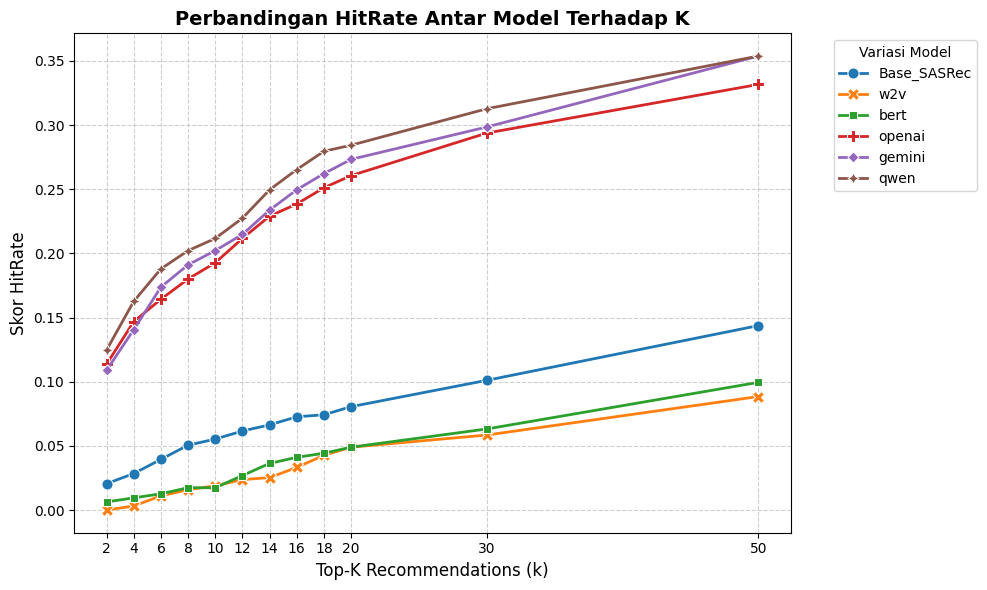

In [12]:
plot_metric_competition(df_master_all_users, 'HitRate', 'Perbandingan HitRate Antar Model Terhadap K')

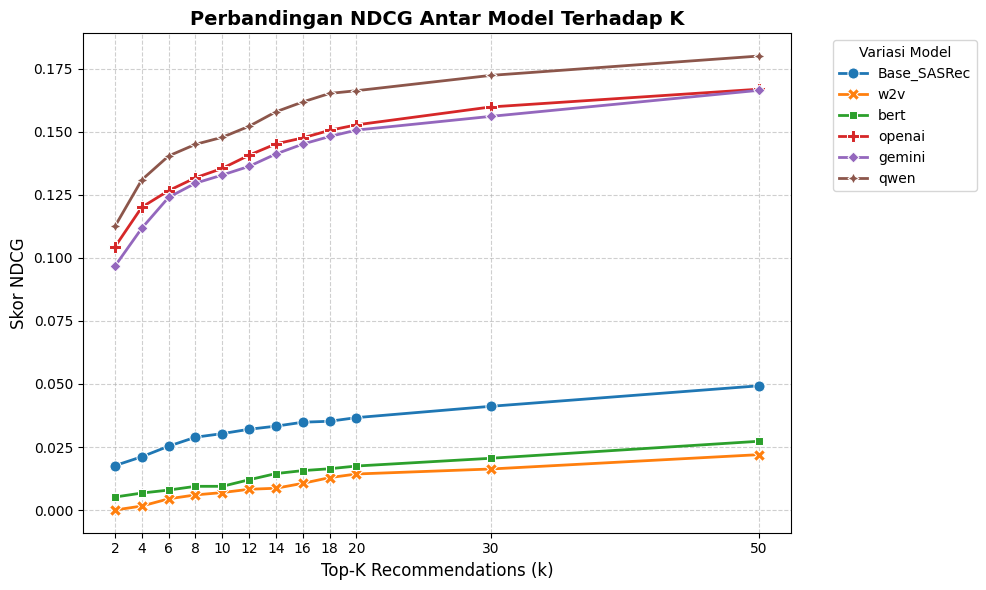

In [13]:
plot_metric_competition(df_master_all_users, 'NDCG', 'Perbandingan NDCG Antar Model Terhadap K')

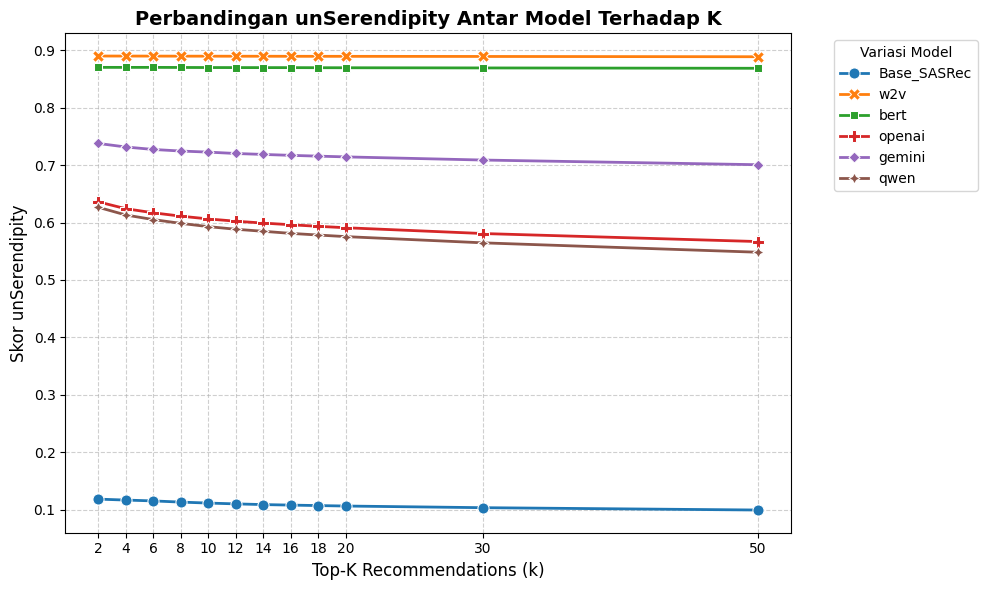

In [14]:
plot_metric_competition(df_master_all_users, 'unSerendipity', 'Perbandingan unSerendipity Antar Model Terhadap K')

# plot_comparison_at_k

In [15]:
def plot_comparison_at_k(df, k_val=10, train_scenario=2, base_model='Base_SASRec', user_type='all'):
    df_k = df[
        (df['k'] == k_val) & 
        (df['User_Type'] == user_type) &
        (
            (df['Train_Scenario'] == train_scenario) | 
            (df['Model'] == base_model)
        )
    ].copy()

    if df_k.empty:
        print(f"Data untuk K={k_val} tidak ditemukan!")
        return
        
    df_melt = df_k.melt(
        id_vars=['Model'],
        value_vars=['HitRate', 'NDCG', 'unSerendipity'],
        var_name='Metrik',
        value_name='Skor'
    )
    
    plt.figure(figsize=(14, 6))
    
    barplot = sns.barplot(
        data=df_melt,
        x='Model', y='Skor', hue='Metrik',
        palette=['#1f77b4', '#ff7f0e', '#2ca02c']
    )
    
    plt.title(f'Perbandingan Seluruh Metrik Antar Model pada Top-{k_val}', fontsize=16, fontweight='bold')
    plt.xlabel('Varian Model', fontsize=12)
    plt.ylabel('Skor Rata-Rata', fontsize=12)
    
    plt.xticks(rotation=30, ha='right')
    
    # Tambahkan angka di atas setiap batang
    for p in barplot.patches:
        val = p.get_height()
        if val > 0: # Cek jika nilai tidak NaN/0
            barplot.annotate(f'{val:.4f}',
                            (p.get_x() + p.get_width() / 2., val),
                            ha = 'center', va = 'center',
                            xytext = (0, 8),
                            textcoords = 'offset points',
                            fontsize=8, rotation=90) # Angka dirotasi agar tidak saling bertumpuk

    plt.legend(title='Metrik')
    plt.tight_layout()
    plt.show()

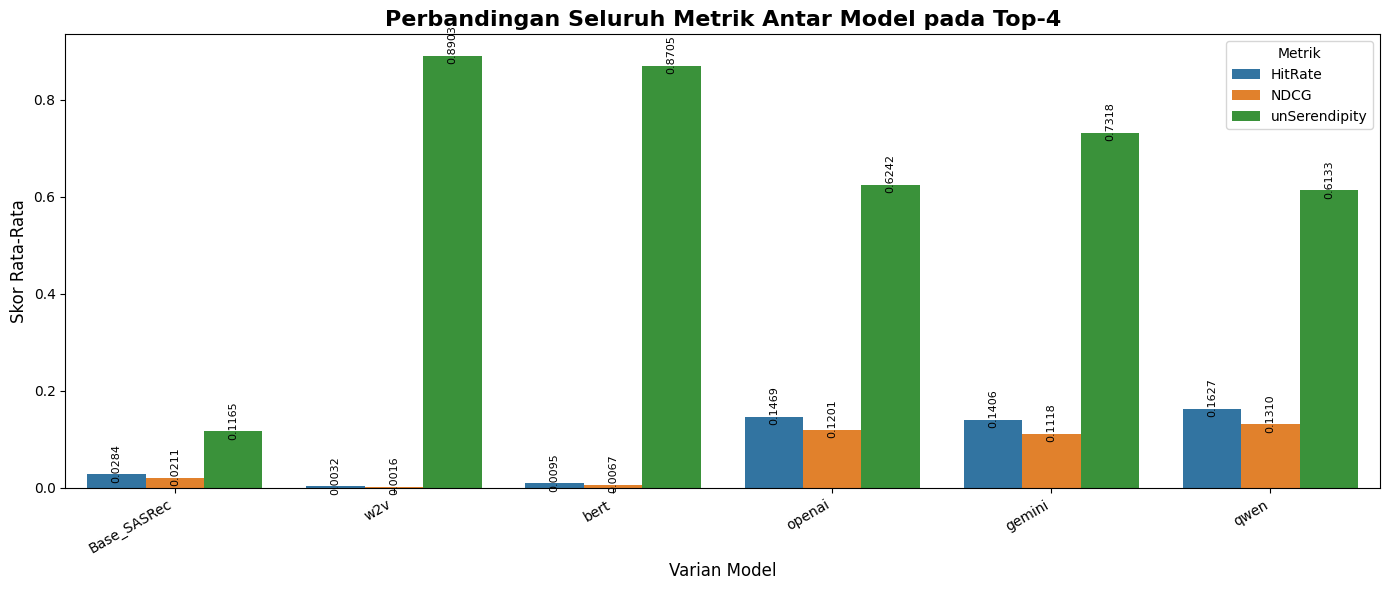

In [16]:
plot_comparison_at_k(df_master_all_users, k_val=4)

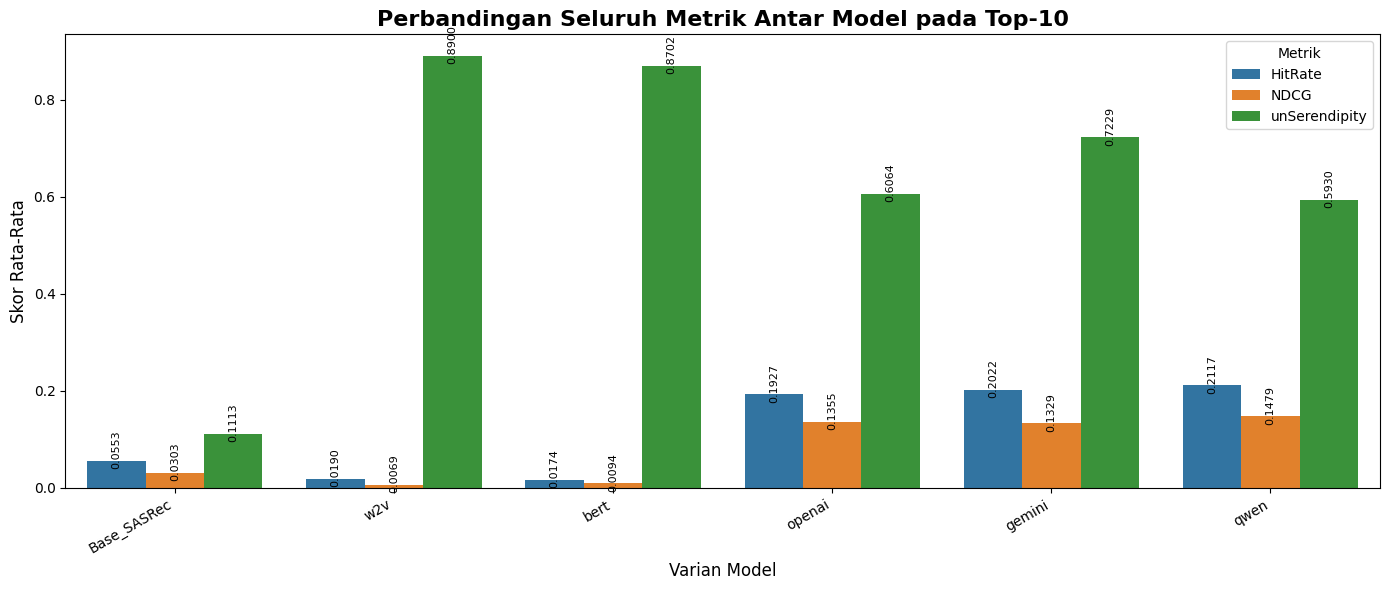

In [17]:
plot_comparison_at_k(df_master_all_users, k_val=10)

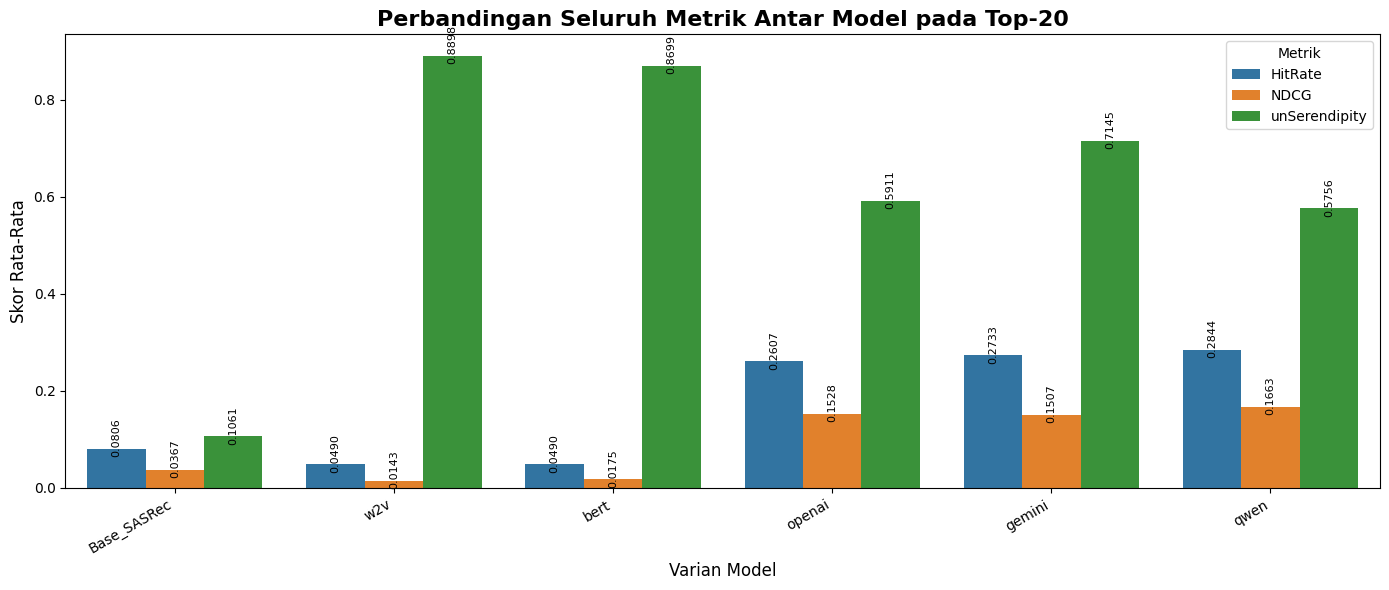

In [18]:
plot_comparison_at_k(df_master_all_users, k_val=20)

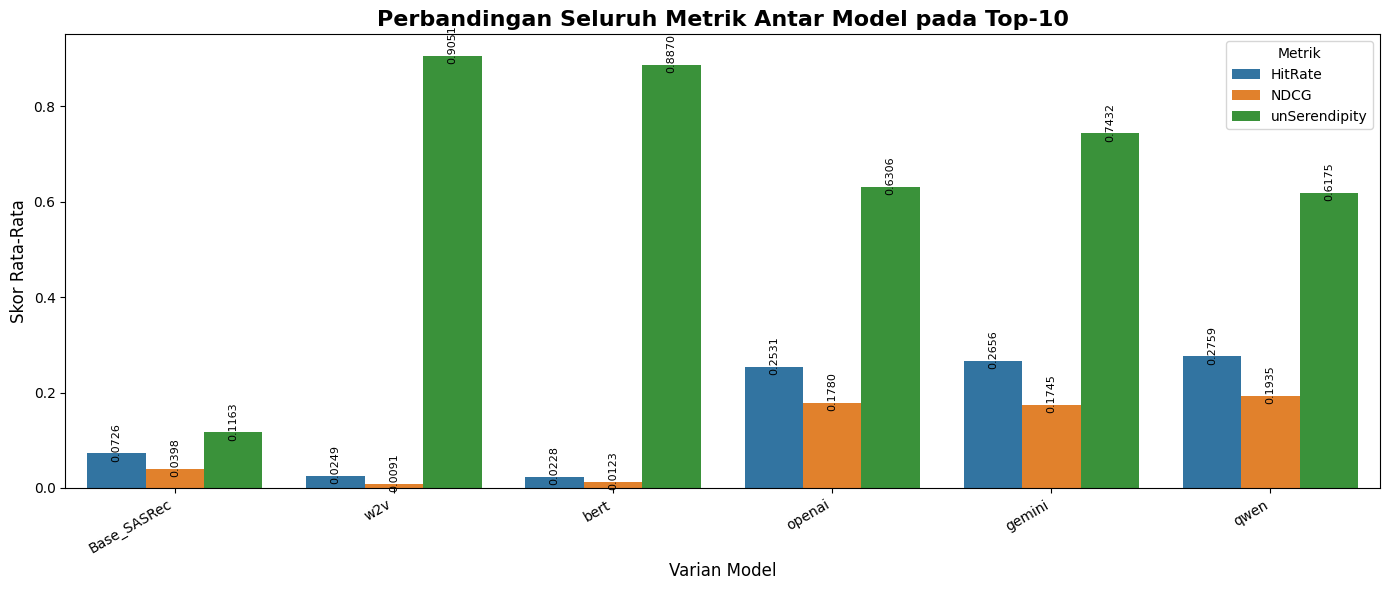

In [19]:
plot_comparison_at_k(df_master, k_val=10, user_type='warm')

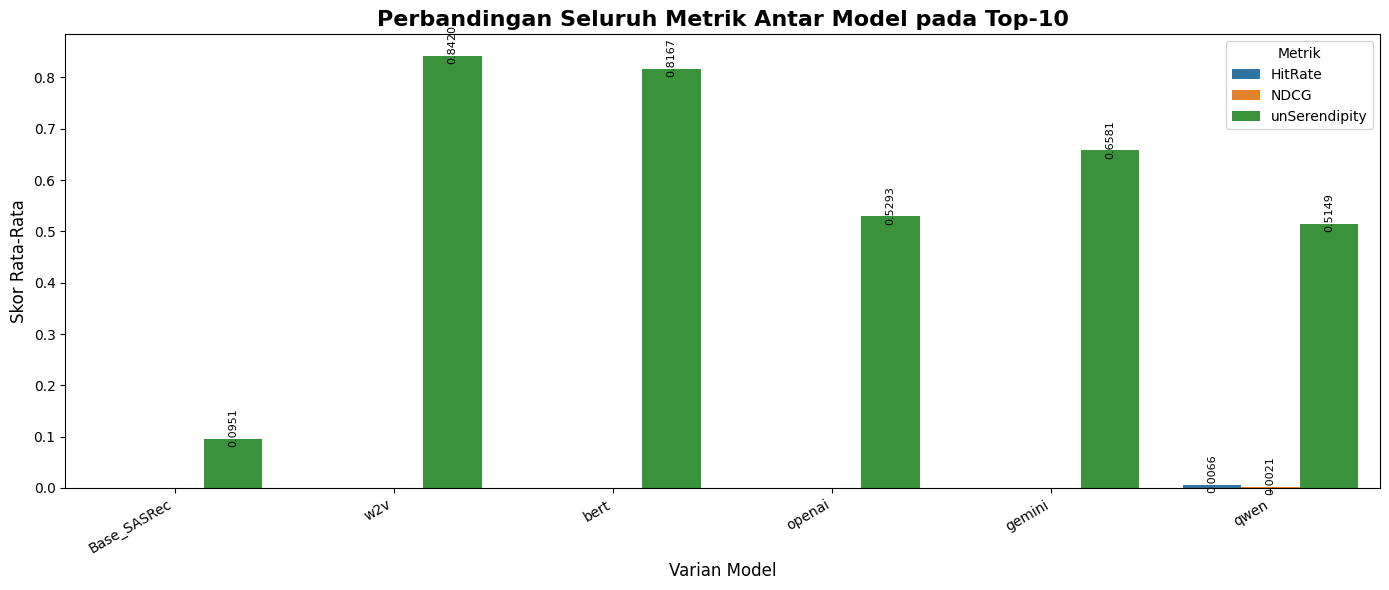

In [20]:
plot_comparison_at_k(df_master, k_val=10, user_type='cold')

# trade off

Scatter Plot: Trade-off Frontier (Akurasi vs Serendipity)
Grafik ini memetakan titik temu terbaik antara akurasi yang tidak terlalu hancur, namun kebaruannya tinggi.

In [21]:
def plot_tradeoff_scatter_2(df, k_val=10, user_type='all'):
    plt.figure(figsize=(10, 6))
    
    # Buat kolom Base_Model secara otomatis jika belum ada
    if 'Base_Model' not in df.columns:
        df['Base_Model'] = df['Model'].apply(lambda x: 'Base_SASRec' if 'Base' in x else x.split('_')[0])
        
    # Filter data
    if 'User_Type' in df.columns:
        df_k = df[(df['User_Type'] == user_type) & (df['k'] == k_val)].copy()
    else:
        df_k = df[df['k'] == k_val].copy()
        
    if df_k.empty:
        print(f"Data tidak ditemukan untuk k={k_val} dan user_type='{user_type}'!")
        return

    # Scatter Plot
    scatter = sns.scatterplot(
        data=df_k,
        x='unSerendipity',
        y='HitRate',
        hue='Model',
        style='Base_Model',
        s=200,
        palette='tab20',
        alpha=0.8,
    )
    
    for i in range(df_k.shape[0]):
        label_text = df_k['Model'].iloc[i]
        
        plt.text(
            df_k['unSerendipity'].iloc[i],
            df_k['HitRate'].iloc[i] + 0.0015,
            label_text,
            horizontalalignment='center',
            fontsize=8, color='black', weight='semibold'
        )

    plt.title(f'Trade-off Frontier: HitRate vs unSerendipity (Top-{k_val}) {"Semua User" if user_type == "all" else user_type}', fontsize=14, fontweight='bold')
    plt.xlabel('unSerendipity (Semakin KIRI Semakin Baik / Serendipity Tinggi)', fontsize=12, color='darkred')
    plt.ylabel('HitRate (Semakin ATAS Semakin Baik / Akurat)', fontsize=12, color='darkgreen')
    
    plt.annotate('Balanced Area\n(Akurat & Beragam)', 
                xy=(0.05, 0.9), xycoords='axes fraction',
                fontsize=10, color='green', weight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", ec="green", alpha=0.3))

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

#### scenario 2

In [22]:
scenario_2 = df_master[(df_master['Train_Scenario'] == 2)]
scenario_2

,User_Type,Weight_Profile,Model,k,HitRate,NDCG,unSerendipity,Train_Scenario,trainable
36,all,NaN,w2v,2,0.000000,0.000000,0.890305,2.0,True
37,all,NaN,w2v,4,0.003160,0.001580,0.890255,2.0,True
38,all,NaN,w2v,6,0.011058,0.004442,0.890199,2.0,True
39,all,NaN,w2v,8,0.015798,0.005993,0.890085,2.0,True
40,all,NaN,w2v,10,0.018957,0.006926,0.890043,2.0,True
...,...,...,...,...,...,...,...,...,...
355,cold,NaN,qwen,16,0.006623,0.002089,0.504356,2.0,True
356,cold,NaN,qwen,18,0.006623,0.002089,0.501263,2.0,True
357,cold,NaN,qwen,20,0.006623,0.002089,0.499086,2.0,True
358,cold,NaN,qwen,30,0.006623,0.002089,0.488728,2.0,True


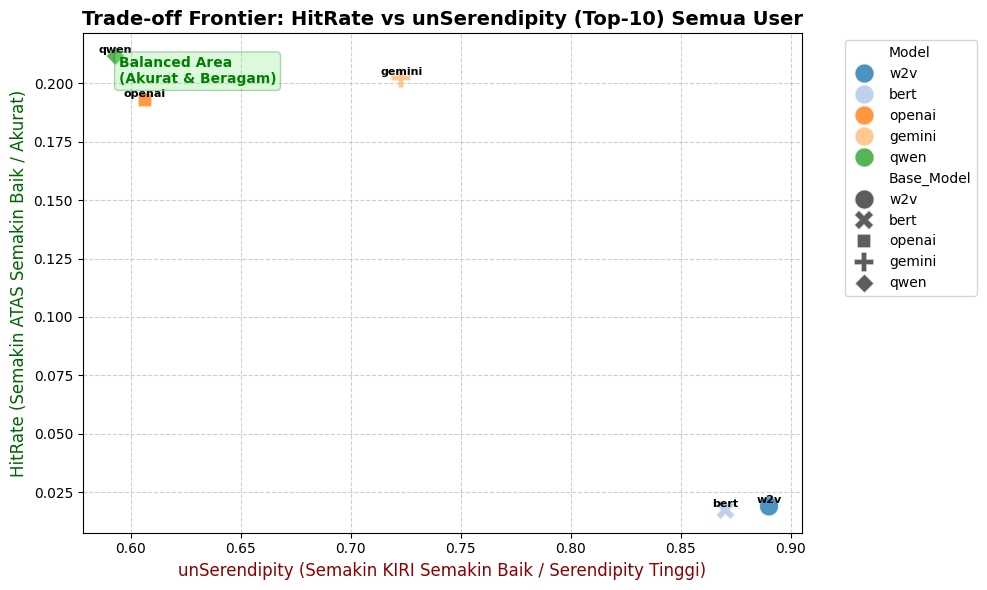

In [23]:
plot_tradeoff_scatter_2(scenario_2, k_val=10, user_type='all')

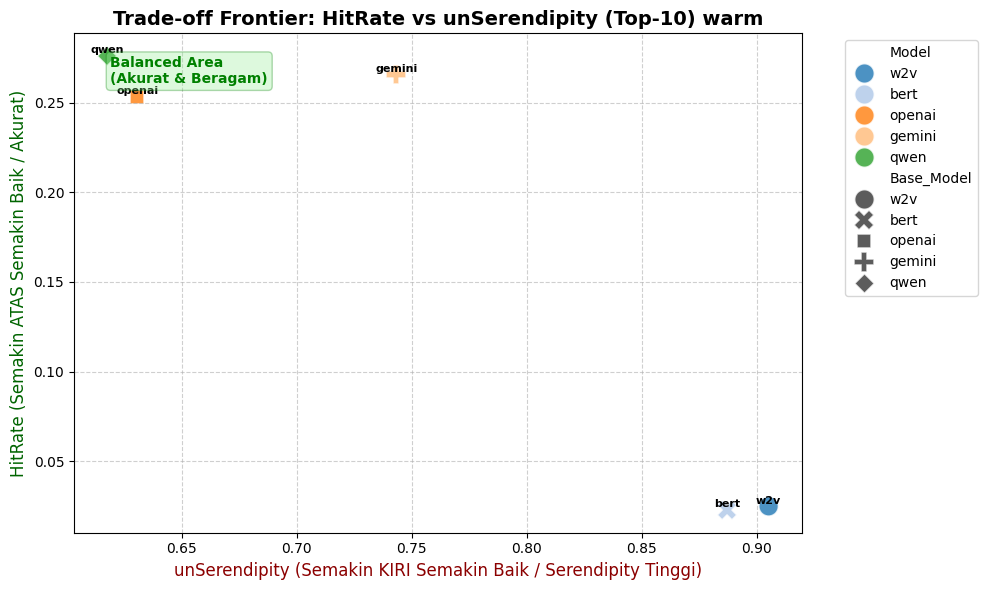

In [24]:
plot_tradeoff_scatter_2(scenario_2, k_val=10, user_type='warm')

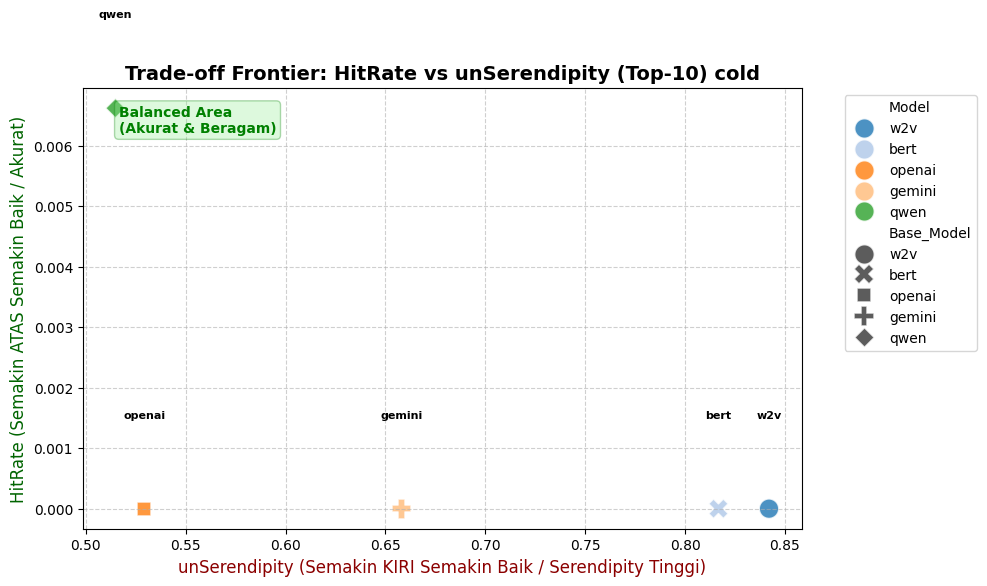

In [25]:
plot_tradeoff_scatter_2(scenario_2, k_val=10, user_type='cold')

#### scenario 3

In [86]:
def plot_tradeoff_scatter_3(df, k_val=10, user_type='all'):
    plt.figure(figsize=(10, 6))
    
    # Buat kolom Base_Model secara otomatis jika belum ada
    if 'Base_Model' not in df.columns:
        df['Base_Model'] = df['Model'].apply(lambda x: 'Base_SASRec' if 'Base' in x else x.split('_')[0])
        
    # Filter data
    if 'User_Type' in df.columns:
        df_k = df[(df['User_Type'] == user_type) & (df['k'] == k_val)].copy()
    else:
        df_k = df[df['k'] == k_val].copy()
        
    if df_k.empty:
        print(f"Data tidak ditemukan untuk k={k_val} dan user_type='{user_type}'!")
        return

    # Scatter Plot
    scatter = sns.scatterplot(
        data=df_k,
        x='unSerendipity',
        y='HitRate',
        hue='Model',
        style='Base_Model',
        s=200,
        palette='tab20',
        alpha=0.8
    )
    
    for i in range(df_k.shape[0]):
        label_text = df_k['Weight_Profile'].iloc[i]
        
        plt.text(
            df_k['unSerendipity'].iloc[i],
            df_k['HitRate'].iloc[i] + 0.0015,
            label_text,
            horizontalalignment='center',
            fontsize=8, color='black', weight='semibold'
        )

    plt.title(f'HitRate vs unSerendipity (Top-{k_val}) - User Type: {user_type}', fontsize=14, fontweight='bold')
    plt.xlabel('unSerendipity (Semakin KIRI Semakin Baik / Serendipity Tinggi)', fontsize=12, color='darkred')
    plt.ylabel('HitRate (Semakin ATAS Semakin Baik / Akurat)', fontsize=12, color='darkgreen')
    
    plt.annotate('Balanced Area\n(Akurat & Beragam)', 
                xy=(0.05, 0.9), xycoords='axes fraction',
                fontsize=10, color='green', weight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", ec="green", alpha=0.3))

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [87]:
scenario_3 = df_master[(df_master['Train_Scenario'] == 3)]
scenario_3

,User_Type,Weight_Profile,Model,k,HitRate,NDCG,unSerendipity,Train_Scenario,trainable,Base_Model
360,all,weight_1,w2v,2,0.000000,0.000000,0.889101,3.0,True,w2v
361,all,weight_1,w2v,4,0.001580,0.000790,0.889091,3.0,True,w2v
362,all,weight_1,w2v,6,0.001580,0.000790,0.889039,3.0,True,w2v
363,all,weight_1,w2v,8,0.001580,0.000790,0.889084,3.0,True,w2v
364,all,weight_1,w2v,10,0.004739,0.001703,0.888933,3.0,True,w2v
...,...,...,...,...,...,...,...,...,...,...
1651,cold,weight_4,qwen,16,0.000000,0.000000,0.139235,3.0,True,qwen
1652,cold,weight_4,qwen,18,0.000000,0.000000,0.140632,3.0,True,qwen
1653,cold,weight_4,qwen,20,0.000000,0.000000,0.142474,3.0,True,qwen
1654,cold,weight_4,qwen,30,0.000000,0.000000,0.149175,3.0,True,qwen


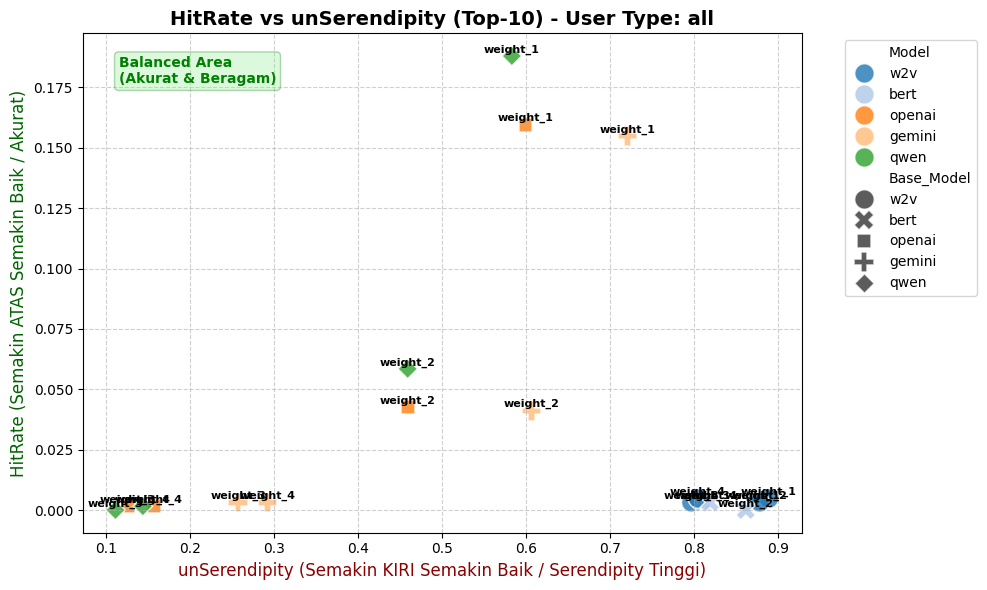

In [88]:
plot_tradeoff_scatter_3(scenario_3, k_val=10, user_type='all')

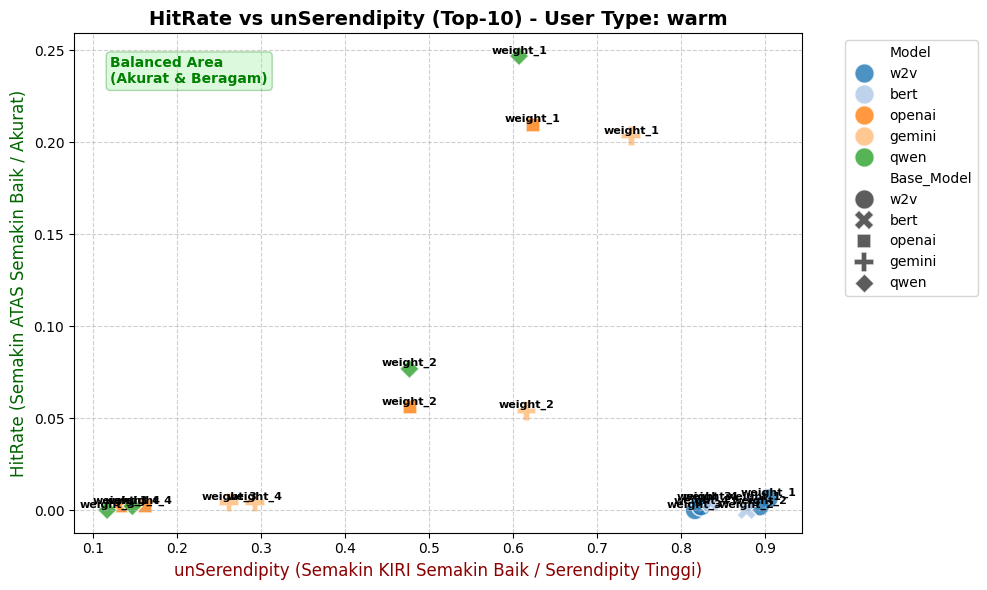

In [89]:
plot_tradeoff_scatter_3(scenario_3, k_val=10, user_type='warm')

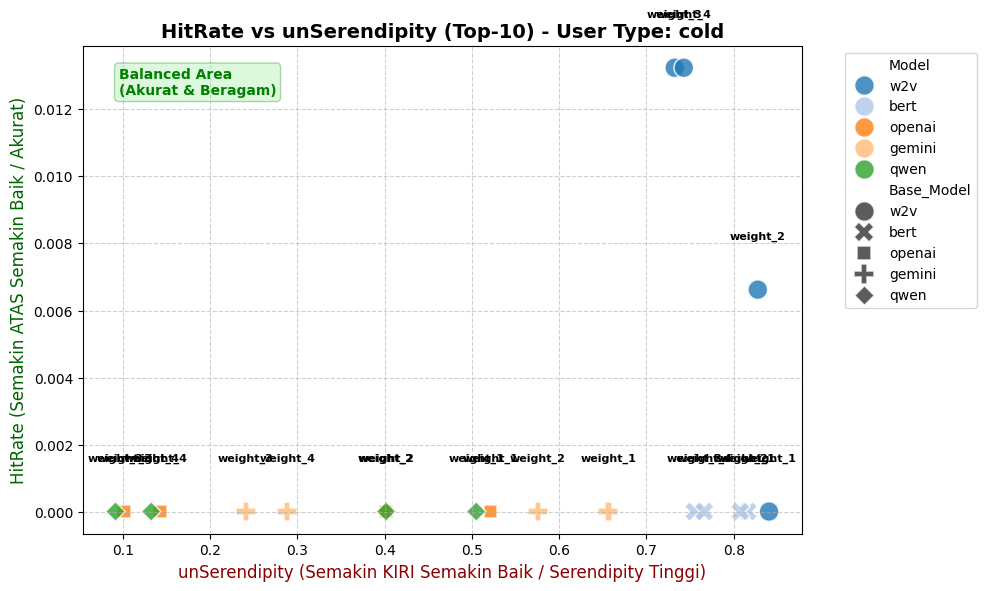

In [90]:
plot_tradeoff_scatter_3(scenario_3, k_val=10, user_type='cold')

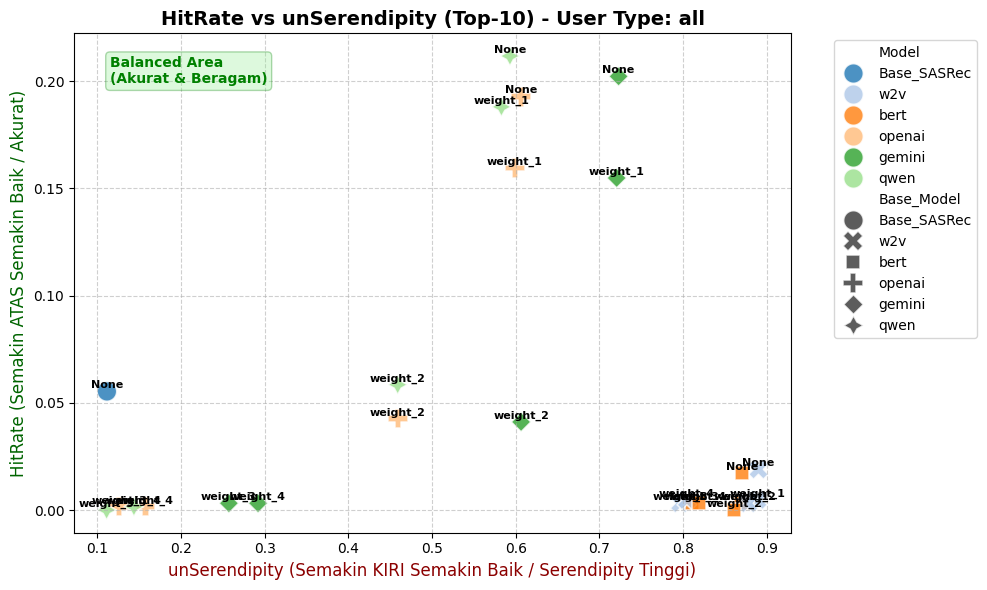

In [91]:
plot_tradeoff_scatter_3(df_master, k_val=10, user_type='all')

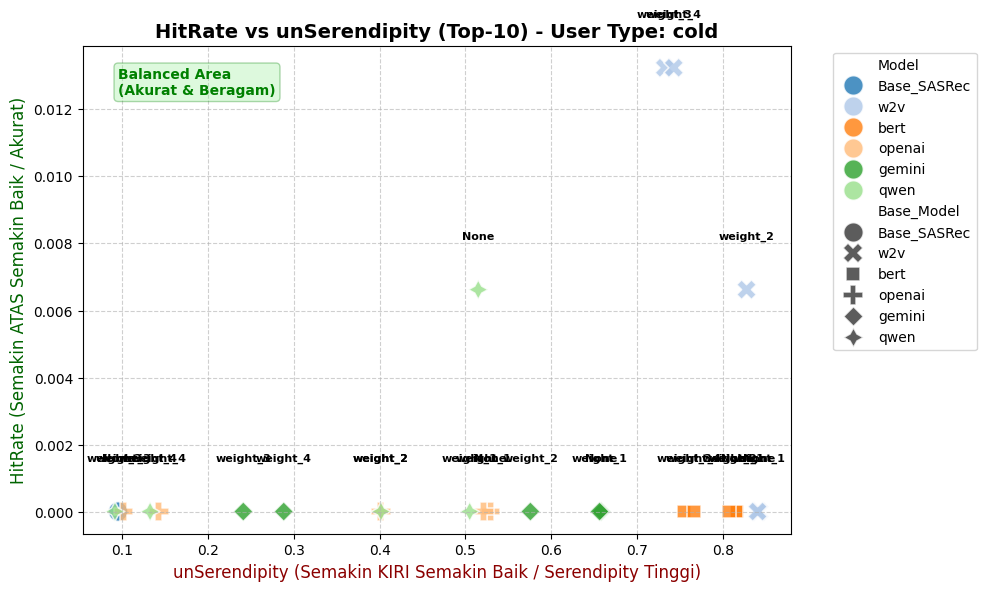

In [92]:
plot_tradeoff_scatter_3(df_master, k_val=10, user_type='cold')

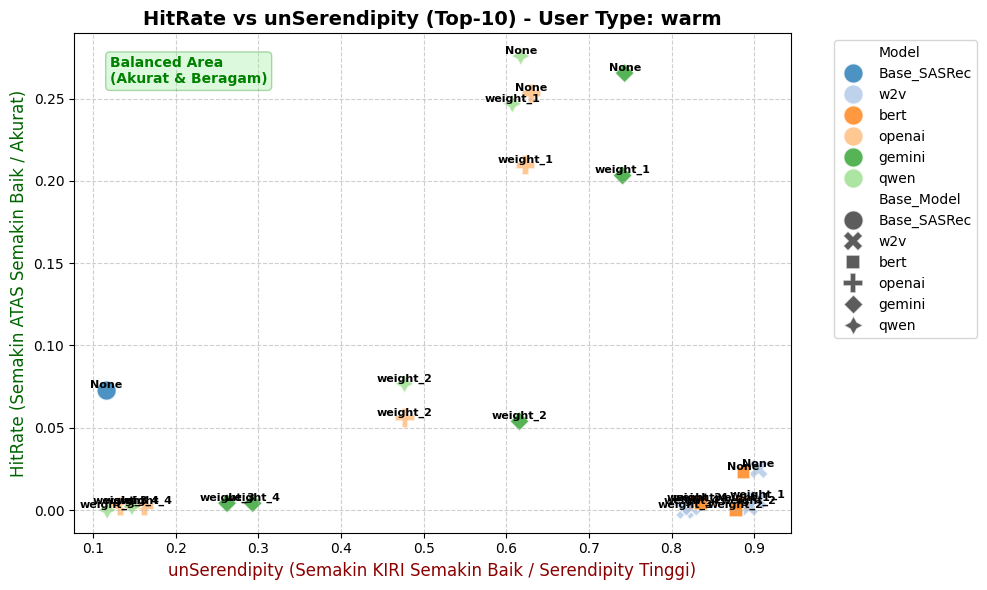

In [93]:
plot_tradeoff_scatter_3(df_master, k_val=10, user_type='warm')

# cold vs warm

Grafik ini akan membuktikan bahwa skenario SOG re-ranking memberikan impak yang berbeda terhadap pengguna baru (Cold) dibanding pengguna lama (Warm).

In [31]:
def plot_cold_vs_warm(df_full, metric='HitRate', k_val=10, weight_profile='None'):
    df_cw = df_full.copy()
    df_cw = df_cw.fillna('None')
    df_cw = df_cw[(df_cw['k'] == k_val) & (df_cw['User_Type'].isin([ 'all', 'warm', 'cold'])) & (df_cw['Weight_Profile'] == weight_profile)]

    if df_cw.empty:
        print("Data Cold/Warm tidak ditemukan!")
        return
        
    plt.figure(figsize=(14, 6))

    barplot = sns.barplot(
        data=df_cw,
        x='Model',
        y=metric,
        hue='User_Type',
        palette=['#9500ff','#f50c0c', '#4287f5'], # Warna (red, blue)
        errorbar=None
    )
    
    plt.title(f'Perbandingan {metric} pada Cold vs Warm Users (Top-{k_val})', fontsize=14, fontweight='bold')
    plt.xlabel('Varian Model', fontsize=12)
    plt.ylabel(f'Skor {metric}', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Tambahkan angka di atas bar
    for p in barplot.patches:
        height = p.get_height()
        if not np.isnan(height) and height >= 0:
            barplot.annotate(f'{height:.3f}',
                            (p.get_x() + p.get_width() / 2., height),
                            ha = 'center', va = 'center',
                            xytext = (0, 8),
                            textcoords = 'offset points',
                            fontsize=9,
                            rotation=0)

    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Tipe Pengguna')
    plt.tight_layout()
    plt.show()

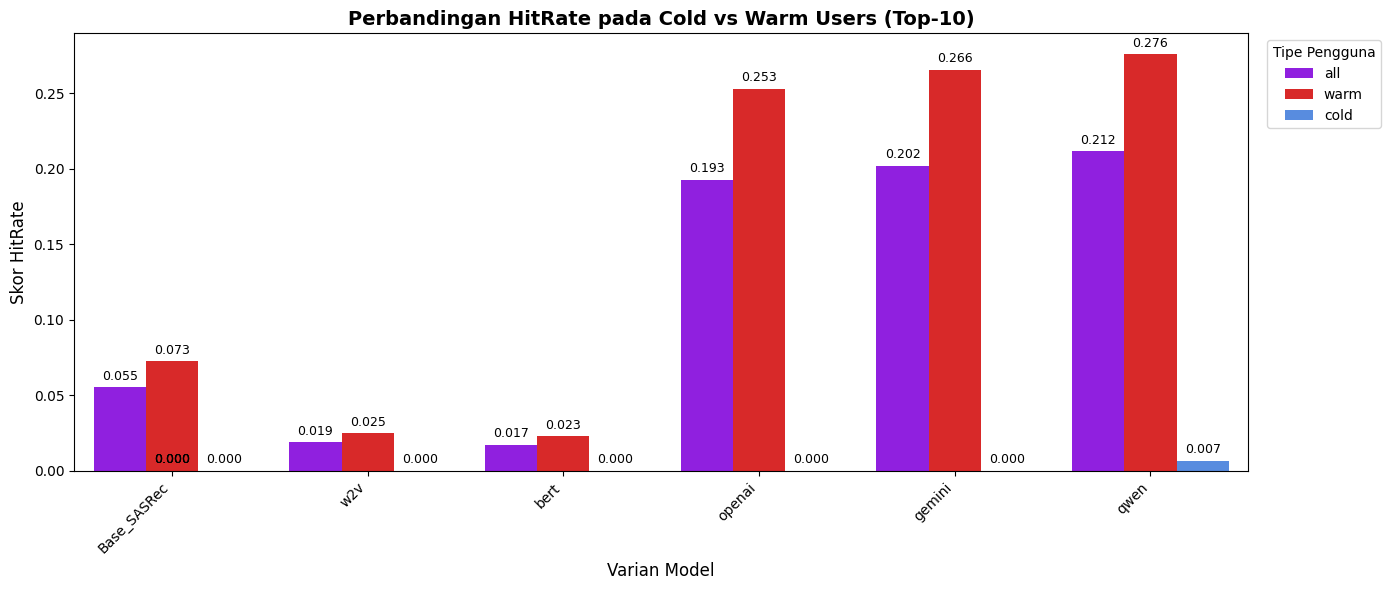

In [32]:
plot_cold_vs_warm(df_master, metric='HitRate', k_val=10)

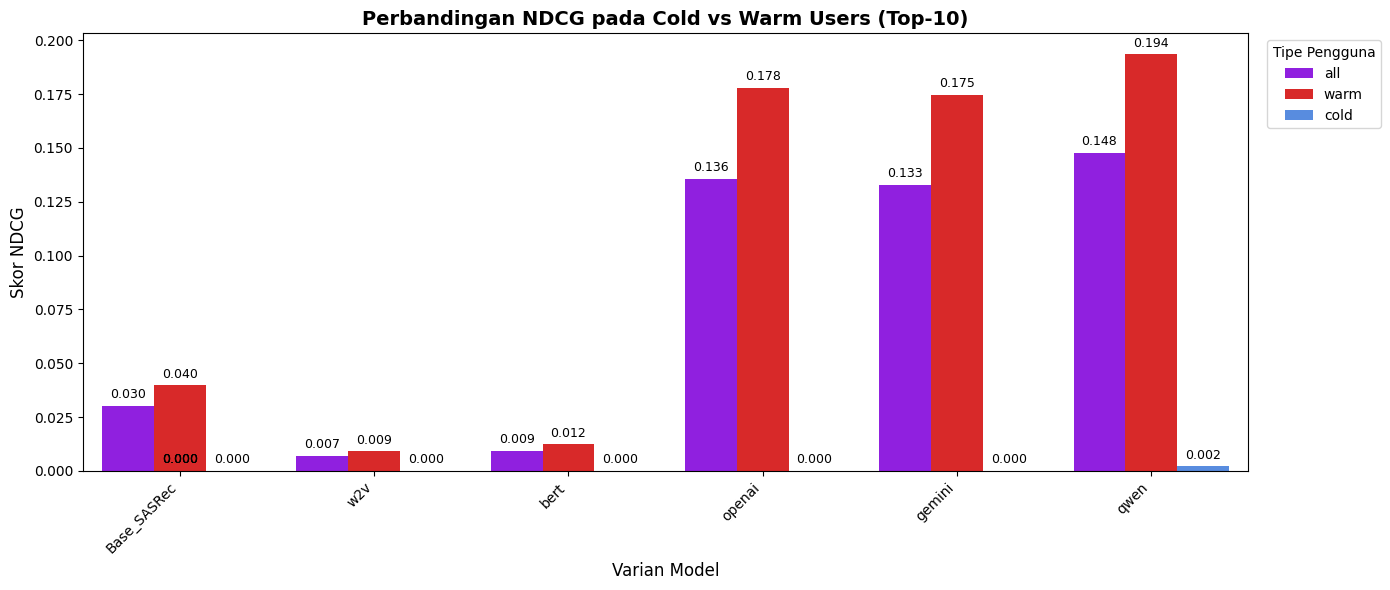

In [33]:

plot_cold_vs_warm(df_master, metric='NDCG', k_val=10)

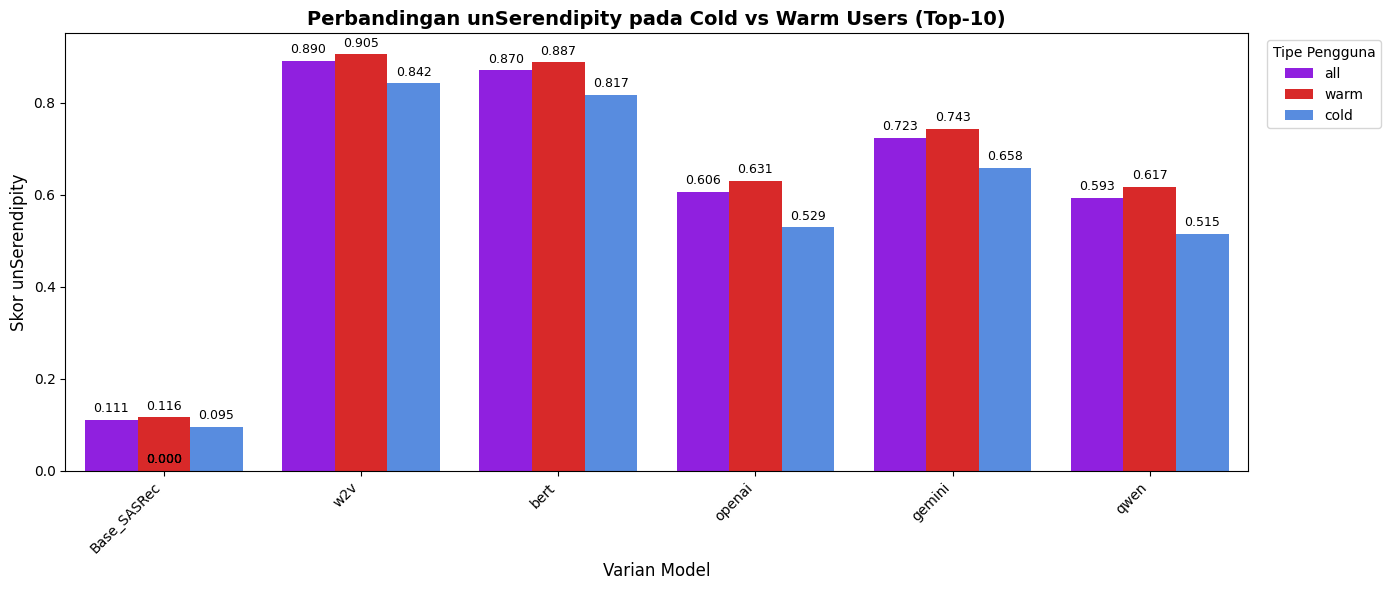

In [34]:

plot_cold_vs_warm(df_master, metric='unSerendipity', k_val=10)

# delta bar

Grafik ini menghitung: "Dibandingkan model Base (0%), seberapa persen kita mengorbankan HitRate demi menaikkan unSerendipity?"

In [54]:
def plot_delta_percentage(df, k_val=10, user_type='all', weight_profile='None'):
    df_k = df.copy()
    df_k = df_k.fillna('None')
    df_k = df_k[(df_k['k'] == k_val) & (df_k['User_Type'] == user_type)]
    df_wp = df_k[df_k['Weight_Profile'] == weight_profile]
    
    # Ambil nilai baseline (Base_SASRec)
    base_row = df_k[df_k['Model'] == 'Base_SASRec']
    if base_row.empty:
        print("Base model tidak ditemukan untuk perhitungan Delta!")
        return
        
    base_hit = base_row['HitRate'].values[0]
    base_ndcg = base_row['NDCG'].values[0]
    base_ser = base_row['unSerendipity'].values[0]
    
    # Hitung persentase perubahan (Delta)
    df_wp['Delta_HitRate (%)'] = ((df_wp['HitRate'] - base_hit) / base_hit) * 100
    df_wp['Delta_unSerendipity (%)'] = ((df_wp['unSerendipity'] - base_ser) / base_ser) * 100
    df_wp['Delta_NDCG (%)'] = ((df_wp['NDCG'] - base_ndcg) / base_ndcg) * 100

    # Buang Base model dari plot agar grafik fokus pada varian model saja
    df_plot = df_wp[df_wp['Model'] != 'Base_SASRec'].copy()
    
    # Melt untuk plotting
    df_melt = df_plot.melt(
        id_vars=['Model'], 
        value_vars=['Delta_HitRate (%)', 'Delta_NDCG (%)', 'Delta_unSerendipity (%)'],
        var_name='Metrik', value_name='Perubahan (%)'
    )
    
    plt.figure(figsize=(12, 6))
    
    # Bar plot (bisa bernilai negatif/positif)
    barplot = sns.barplot(
        data=df_melt,
        x='Model',
        y='Perubahan (%)',
        hue='Metrik',
        palette=['#d62728', '#2ca02c', '#3c6bfa'],
        errorbar=None
    )
    
    # Garis nol (Baseline)
    plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
    
    weight_label = '' if weight_profile == 'None' else weight_profile
    plt.title(f'Persentase Perubahan Performa terhadap Model Base (Top-{k_val}) pada {user_type} test set {weight_label}', fontsize=14, fontweight='bold')
    plt.xlabel('Varian Model', fontsize=12)
    plt.ylabel('Perubahan (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Label nilai persen
    for p in barplot.patches:
        val = p.get_height()
        if not np.isnan(val):
            # Posisi teks: Jika positif di atas bar, jika negatif di bawah bar
            y_offset = 6 if val > 0 else -8
            barplot.annotate(f'{val:+.1f}%',
                            (p.get_x() + p.get_width() / 2., val), 
                            ha = 'center', va = 'center', 
                            xytext = (0, y_offset),
                            textcoords = 'offset points',
                            fontsize=8, fontweight='bold')

    plt.legend(title='Metrik vs Base')
    plt.tight_layout()
    plt.show()

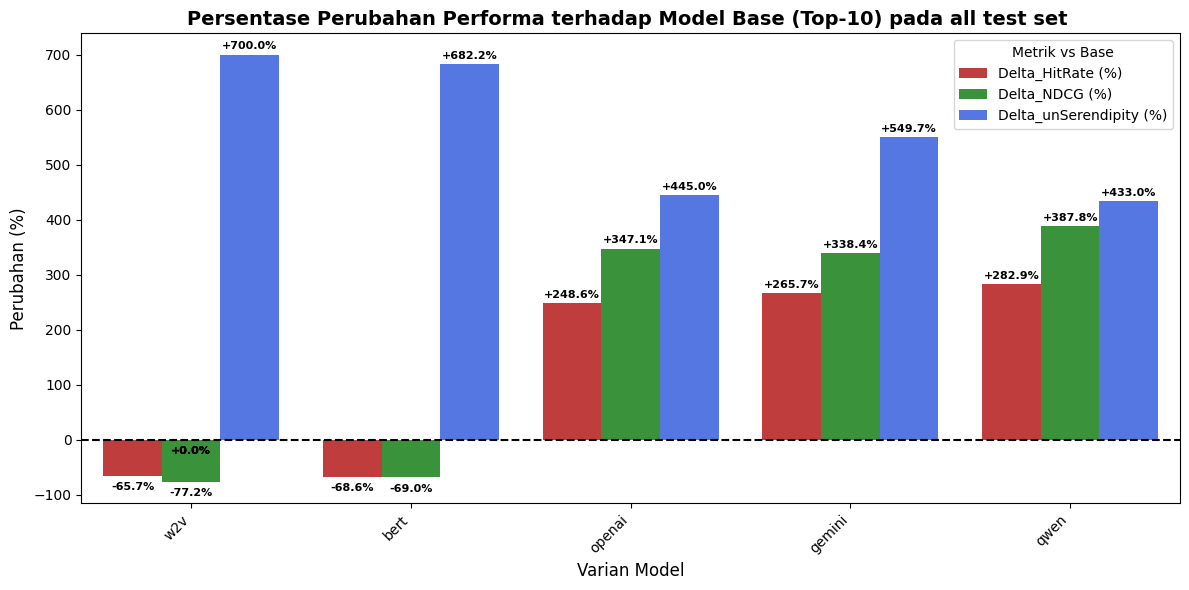

In [55]:
plot_delta_percentage(df_master_all_users, k_val=10)

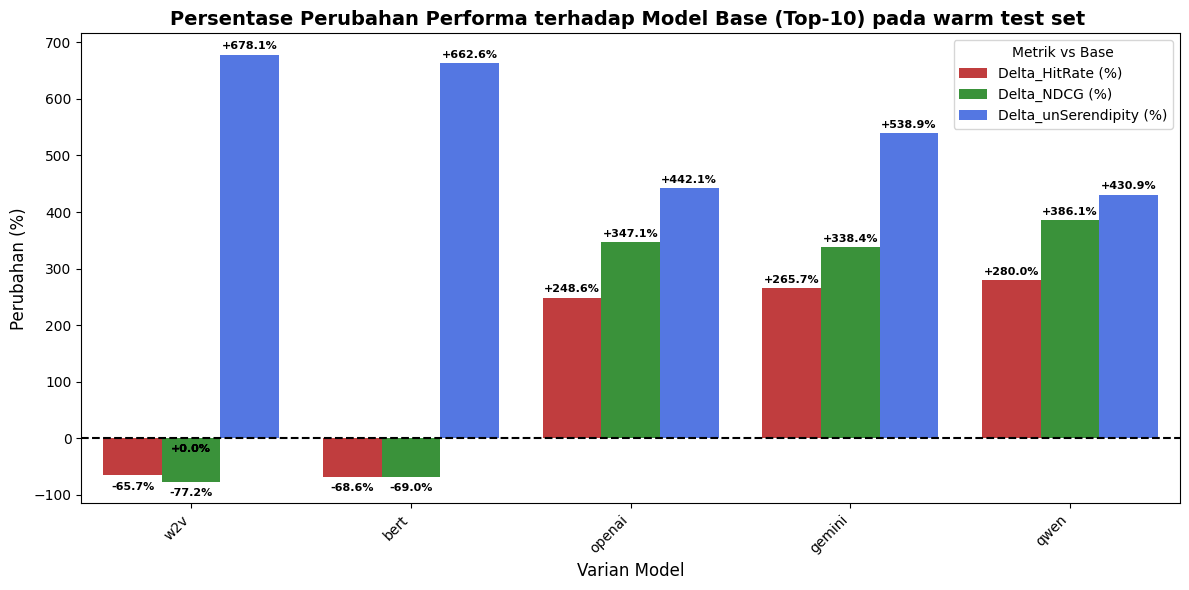

In [56]:
plot_delta_percentage(df_master, k_val=10, user_type='warm')

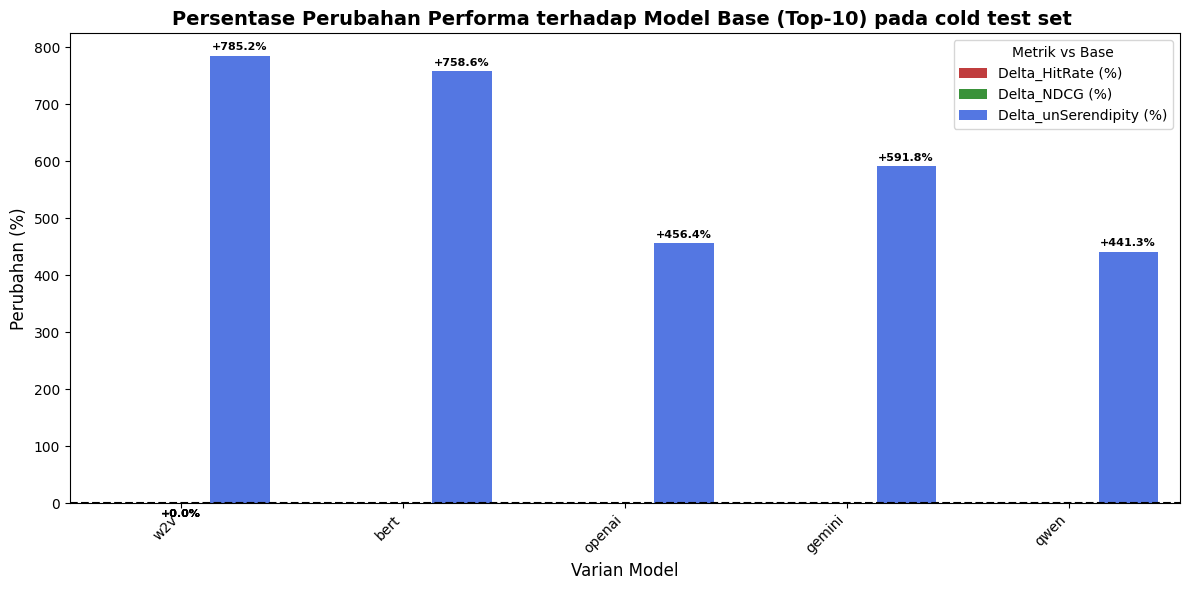

In [57]:
plot_delta_percentage(df_master, k_val=10, user_type='cold')

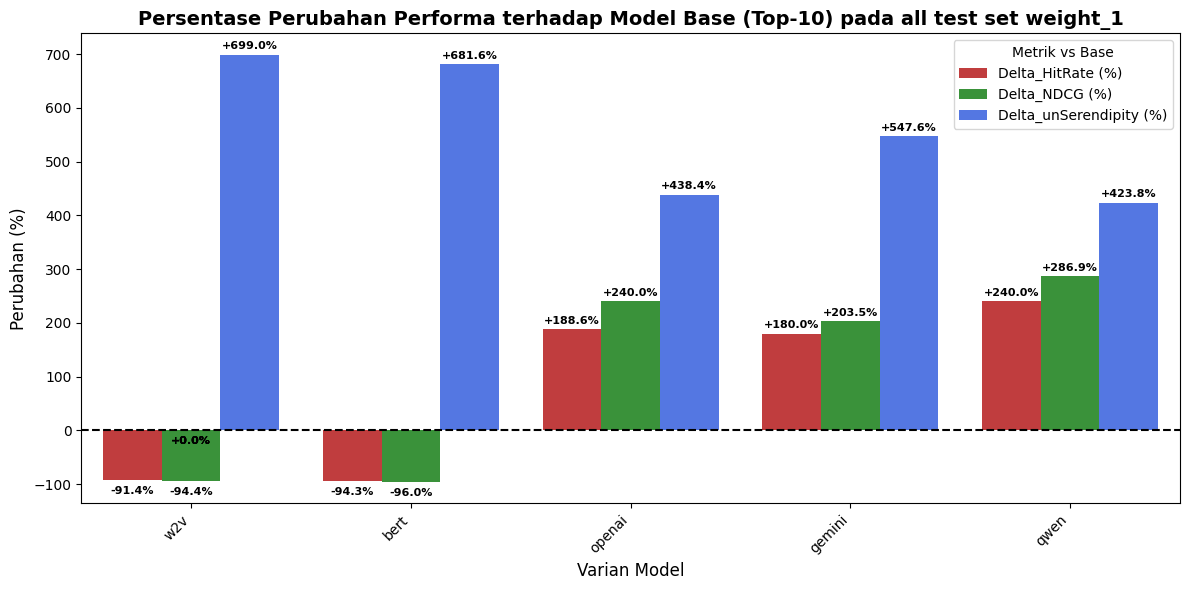

In [58]:
plot_delta_percentage(df_master, k_val=10, user_type='all', weight_profile='weight_1')

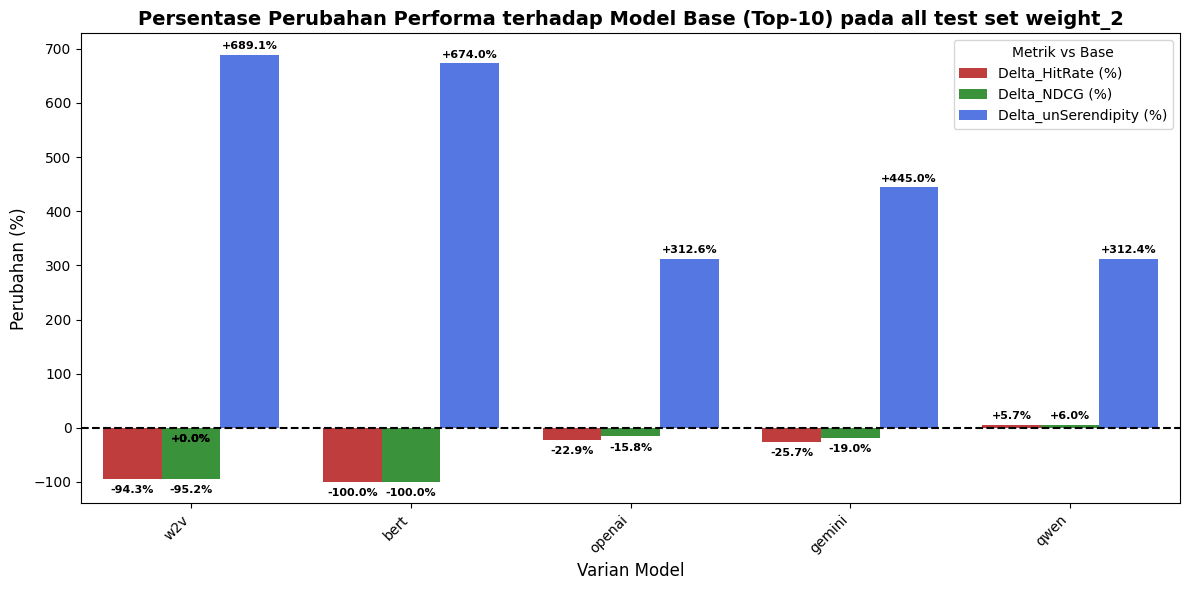

In [59]:
plot_delta_percentage(df_master, k_val=10, user_type='all', weight_profile='weight_2')

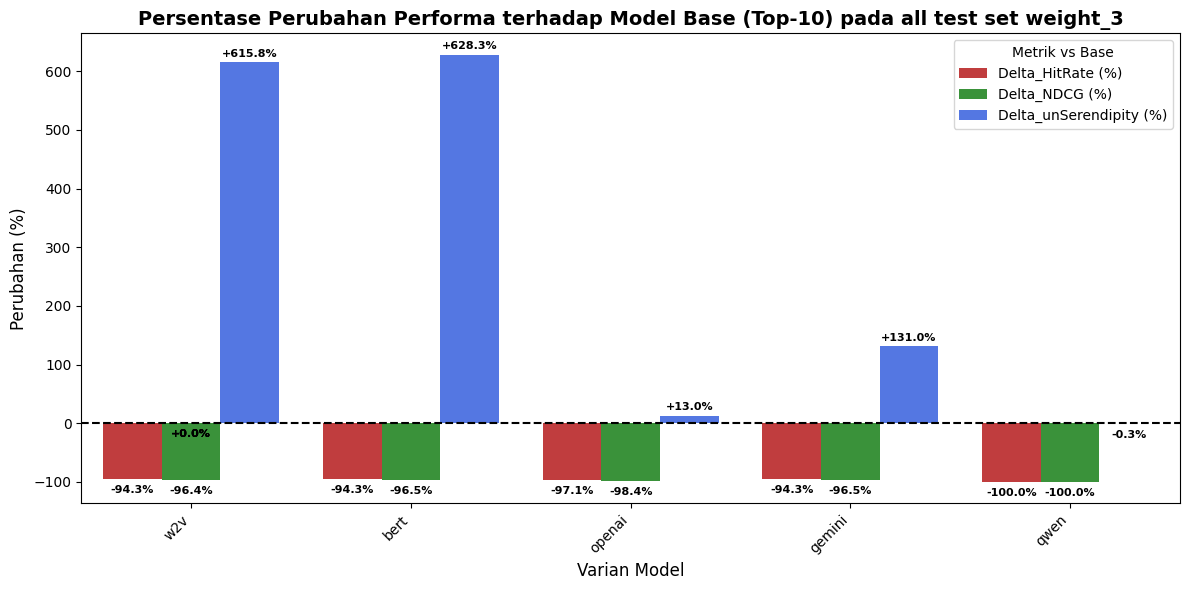

In [60]:
plot_delta_percentage(df_master, k_val=10, user_type='all', weight_profile='weight_3')

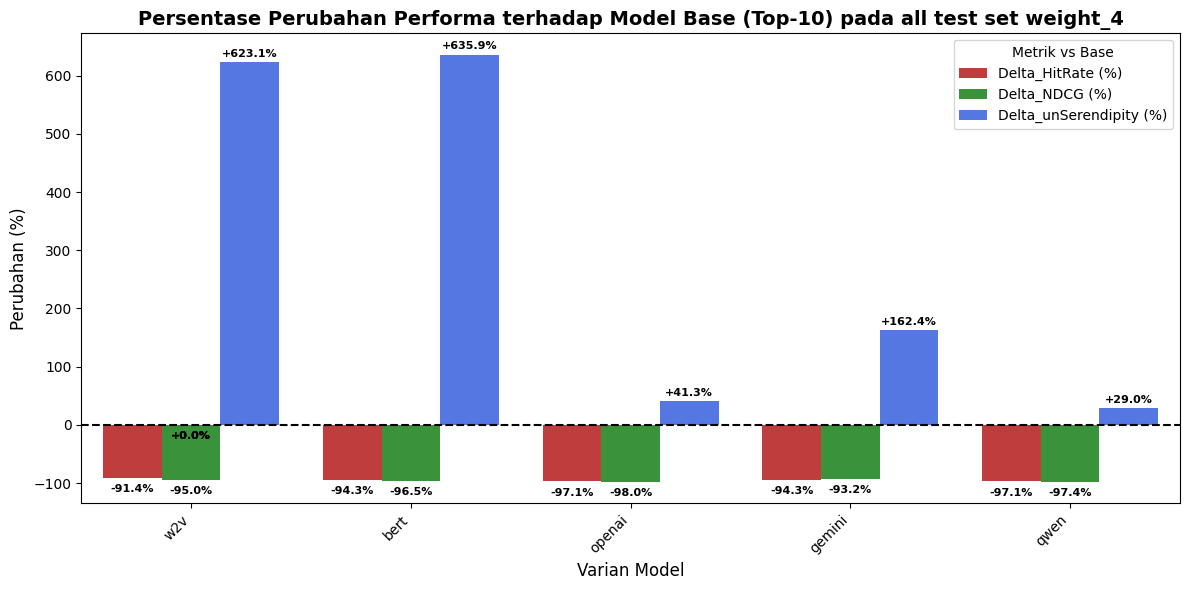

In [61]:
plot_delta_percentage(df_master, k_val=10, user_type='all', weight_profile='weight_4')

# Table

In [51]:
def summary_table(df, k_val=10, weight_profile='None', user_type='none'):
    df_k = df.copy()
    df_k = df_k.fillna('None')
    if user_type == 'none':
        df_k = df_k[(df_k['k'] == k_val) & (df_k['Weight_Profile'] == weight_profile)]
    else:
        df_k = df_k[(df_k['k'] == k_val) & (df_k['Weight_Profile'] == weight_profile) & (df_k['User_Type'] == user_type)]
    
    df_k = df_k[['Model', 'User_Type', 'HitRate', 'NDCG', 'unSerendipity']]
    
    df_k = df_k.rename(columns={
        'Model': 'Varian Model',
        'User_Type': 'Skenario',
        'HitRate': f'HitRate@{k_val}',
        'NDCG': f'NDCG@{k_val}',
        'unSerendipity': f'unSerendipity@{k_val}'
    })
    
    df_k['Skenario'] = df_k['Skenario'].str.capitalize()
    
    df_k['Skenario'] = pd.Categorical(df_k['Skenario'], categories=['Warm', 'Cold'], ordered=True)
    df_k = df_k.sort_values(by=['Varian Model', 'Skenario']).reset_index(drop=True)
    
    tabel_rapi = df_k.style.format({
        f'HitRate@{k_val}': '{:.3f}',
        f'NDCG@{k_val}': '{:.3f}',
        f'unSerendipity@{k_val}': '{:.3f}'
    }).hide(axis="index")
    display(tabel_rapi)

In [52]:
summary_table(df_master, k_val=10, weight_profile='None', user_type='none')

C:\Users\reera\AppData\Local\Temp\ipykernel_17172\2302122942.py:21: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df_k['Skenario'] = pd.Categorical(df_k['Skenario'], categories=['Warm', 'Cold'], ordered=True)


Varian Model,Skenario,HitRate@10,NDCG@10,unSerendipity@10
Base_SASRec,Warm,0.073,0.040,0.116
Base_SASRec,Cold,0.000,0.000,0.095
Base_SASRec,nan,0.055,0.030,0.111
bert,Warm,0.023,0.012,0.887
bert,Cold,0.000,0.000,0.817
bert,nan,0.017,0.009,0.870
gemini,Warm,0.266,0.175,0.743
gemini,Cold,0.000,0.000,0.658
gemini,nan,0.202,0.133,0.723
openai,Warm,0.253,0.178,0.631


In [53]:
summary_table(df_master, k_val=10, weight_profile='None', user_type='all')

C:\Users\reera\AppData\Local\Temp\ipykernel_17172\2302122942.py:21: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df_k['Skenario'] = pd.Categorical(df_k['Skenario'], categories=['Warm', 'Cold'], ordered=True)


Varian Model,Skenario,HitRate@10,NDCG@10,unSerendipity@10
Base_SASRec,nan,0.055,0.030,0.111
bert,nan,0.017,0.009,0.870
gemini,nan,0.202,0.133,0.723
openai,nan,0.193,0.136,0.606
qwen,nan,0.212,0.148,0.593
w2v,nan,0.019,0.007,0.890


# T-paired test

In [45]:
from scipy import stats

def paired_t_test(df, model_baseline, model_eksperimen, metric, user_type='all'):
    """
    Melakukan Paired T-Test antara dua model berdasarkan K yang sama.
    """
    df_base = df[(df['Model'] == model_baseline) & (df['User_Type'] == user_type)].copy()
    df_eksp = df[(df['Model'] == model_eksperimen) & (df['User_Type'] == user_type)].copy()

    df_base = df_base.fillna('None')
    df_eksp = df_eksp.fillna('None')
    
    df_base = df_base[df_base['Weight_Profile'] == 'None']
    df_eksp = df_eksp[df_eksp['Weight_Profile'] == 'None']
    
    # Pastikan data diurutkan berdasarkan 'k' agar pasangannya tepat (K=2 di-pair dgn K=2)
    df_base = df_base.sort_values('k').reset_index(drop=True)
    df_eksp = df_eksp.sort_values('k').reset_index(drop=True)
    
    # Validasi jumlah sampel
    if len(df_base) != len(df_eksp) or len(df_base) == 0:
        print(f"Error: Data tidak seimbang untuk di-pair. {model_baseline} punya {len(df_base)} baris, {model_eksperimen} punya {len(df_eksp)} baris.")
        return
        
    skor_base = df_base[metric].values
    skor_eksp = df_eksp[metric].values
    
    # Uji Statistik (Sekarang sampel N = jumlah variasi K)
    t_stat, p_value = stats.ttest_rel(skor_base, skor_eksp)
    
    alpha = 0.05
    rata_base = skor_base.mean()
    rata_eksp = skor_eksp.mean()
    
    is_significant = p_value < alpha
    
    # Cek apakah eksperimen lebih baik
    if metric == 'unSerendipity':
        # unSerendipity lebih kecil = novelty lebih tinggi / serendipity lebih baik
        lebih_baik = rata_eksp < rata_base # <-- SAYA PERBAIKI LOGIKANYA DI SINI (LEBIH KECIL LEBIH BAIK)
    else:
        # HitRate / NDCG lebih besar = lebih baik
        lebih_baik = rata_eksp > rata_base
    
    print(f"--- UJI PAIRED T-TEST: {model_baseline} vs {model_eksperimen} ---")
    print(f"Metrik      : {metric} (Skenario: {user_type})")
    print(f"Rata-rata   : {model_baseline} = {rata_base:.4f} | {model_eksperimen} = {rata_eksp:.4f}")
    print(f"T-Statistic : {t_stat:.4f}")
    print(f"P-Value     : {p_value:.5f}") # Format 5 desimal agar p-value yg kecil (misal 0.0001) terlihat
    
    if is_significant:
        keterangan = "LEBIH BAIK secara SIGNIFIKAN" if lebih_baik else "MENURUN secara SIGNIFIKAN"
        print(f"Kesimpulan  : Performa {model_eksperimen} {keterangan} dibandingkan {model_baseline} (p < 0.05).")
    else:
        print("Kesimpulan  : Perbedaan performa TIDAK SIGNIFIKAN secara statistik (p >= 0.05).")
    print("-" * 60)


In [46]:
paired_t_test(df_master, model_baseline='Base_SASRec', model_eksperimen='qwen', metric='HitRate', user_type='all')

--- UJI PAIRED T-TEST: Base_SASRec vs qwen ---
Metrik      : HitRate (Skenario: all)
Rata-rata   : Base_SASRec = 0.0662 | qwen = 0.2385
T-Statistic : -17.3883
P-Value     : 0.00000
Kesimpulan  : Performa qwen LEBIH BAIK secara SIGNIFIKAN dibandingkan Base_SASRec (p < 0.05).
------------------------------------------------------------


In [47]:
def significant_test(df, model_baseline='Base_SASRec', metric='HitRate', user_type='all'):
    hasil_uji = []
    
    # Dapatkan semua model eksperimen selain baseline
    model_eksperimen_list = [m for m in df['Model'].unique() if m != model_baseline]
    
    for model_eksp in model_eksperimen_list:
        # Filter & Sort
        df_base = df[(df['Model'] == model_baseline) & (df['User_Type'] == user_type)].copy()
        df_eksp = df[(df['Model'] == model_eksp) & (df['User_Type'] == user_type)].copy()

        df_base = df_base.fillna('None')
        df_eksp = df_eksp.fillna('None')
        
        df_base = df_base[df_base['Weight_Profile'] == 'None']
        df_eksp = df_eksp[df_eksp['Weight_Profile'] == 'None']
        
        if len(df_base) == len(df_eksp) and len(df_base) > 0:
            skor_base = df_base[metric].values
            skor_eksp = df_eksp[metric].values
            
            # Hitung T-Test
            t_stat, p_value = stats.ttest_rel(skor_base, skor_eksp)
            rata_base = skor_base.mean()
            rata_eksp = skor_eksp.mean()
            selisih = rata_eksp - rata_base
            
            hasil_uji.append({
                'Model Eksperimen': model_eksp,
                'Rata-rata Base': rata_base,
                'Rata-rata Eksp': rata_eksp,
                'Selisih': selisih,
                'P-Value': p_value,
                'Signifikan (p < 0.05)': "Ya" if p_value < 0.05 else "Tidak"
            })
            
    # Jadikan dataframe agar rapi
    df_hasil = pd.DataFrame(hasil_uji)
    
    # Berikan gaya formatting pada tabel
    tabel_rapi = df_hasil.style.format({
        'Rata-rata Base': '{:.4f}',
        'Rata-rata Eksp': '{:.4f}',
        'Selisih': '{:+.4f}',
        'P-Value': '{:.5f}'
    }).hide(axis="index")
    
    print(f"REKAP UJI SIGNIFIKANSI {metric.upper()} PADA SKENARIO '{user_type.upper()}'")
    print(f"(Baseline: {model_baseline})")
    display(tabel_rapi)

In [48]:
significant_test(df_master, model_baseline='Base_SASRec', metric='HitRate', user_type='cold')

REKAP UJI SIGNIFIKANSI HITRATE PADA SKENARIO 'COLD'
(Baseline: Base_SASRec)


Model Eksperimen,Rata-rata Base,Rata-rata Eksp,Selisih,P-Value,Signifikan (p < 0.05)
w2v,0.0000,0.0000,+0.0000,nan,Tidak
bert,0.0000,0.0000,+0.0000,nan,Tidak
openai,0.0000,0.0039,+0.0039,0.00238,Ya
gemini,0.0000,0.0000,+0.0000,nan,Tidak
qwen,0.0000,0.0055,+0.0055,0.00040,Ya


In [49]:
significant_test(df_master, model_baseline='Base_SASRec', metric='HitRate', user_type='warm')

REKAP UJI SIGNIFIKANSI HITRATE PADA SKENARIO 'WARM'
(Baseline: Base_SASRec)


Model Eksperimen,Rata-rata Base,Rata-rata Eksp,Selisih,P-Value,Signifikan (p < 0.05)
w2v,0.0870,0.0405,-0.0465,0.00000,Ya
bert,0.0870,0.0463,-0.0406,0.00000,Ya
openai,0.0870,0.2849,+0.1980,0.00000,Ya
gemini,0.0870,0.2958,+0.2089,0.00000,Ya
qwen,0.0870,0.3115,+0.2246,0.00000,Ya


In [50]:
significant_test(df_master, model_baseline='Base_SASRec', metric='HitRate', user_type='all')

REKAP UJI SIGNIFIKANSI HITRATE PADA SKENARIO 'ALL'
(Baseline: Base_SASRec)


Model Eksperimen,Rata-rata Base,Rata-rata Eksp,Selisih,P-Value,Signifikan (p < 0.05)
w2v,0.0662,0.0308,-0.0354,0.00000,Ya
bert,0.0662,0.0353,-0.0309,0.00000,Ya
openai,0.0662,0.2179,+0.1517,0.00000,Ya
gemini,0.0662,0.2253,+0.1590,0.00000,Ya
qwen,0.0662,0.2385,+0.1723,0.00000,Ya


## compact summary

In [66]:
def compact_table(df, model_baseline='Base_SASRec'):
    hasil_uji = []
    
    # Dapatkan semua model eksperimen selain baseline
    model_eksperimen_list = [m for m in df['Model'].unique() if m != model_baseline]
    
    # Dapatkan seluruh User_Type unik yang ada di dataset
    all_user_types = df['User_Type'].unique()
    
    for u_type in all_user_types:
        # Siapkan data baseline spesifik untuk User_Type saat ini
        df_base_all = df[(df['Model'] == model_baseline) & (df['User_Type'] == u_type)].copy().fillna('None')
        df_base_all = df_base_all[df_base_all['Weight_Profile'] == 'None']
        
        if df_base_all.empty:
            continue

        base_hr_mean = df_base_all['HitRate'].mean()
        base_ndcg_mean = df_base_all['NDCG'].mean()
        base_ser_mean = df_base_all['unSerendipity'].mean()
        
        for model_eksp in model_eksperimen_list:
            df_eksp = df[(df['Model'] == model_eksp) & (df['User_Type'] == u_type)].copy().fillna('None')
            df_eksp = df_eksp[df_eksp['Weight_Profile'] == 'None']
            
            # Sinkronisasi baris data berdasarkan nilai 'k' agar Paired T-Test valid
            df_base_clean = df_base_all[df_base_all['k'].isin(df_eksp['k'])].sort_values('k')
            df_eksp_clean = df_eksp[df_eksp['k'].isin(df_base_clean['k'])].sort_values('k')
            
            if len(df_base_clean) == len(df_eksp_clean) and len(df_base_clean) > 0:
                hr_base, hr_eksp = df_base_clean['HitRate'].values, df_eksp_clean['HitRate'].values
                ndcg_base, ndcg_eksp = df_base_clean['NDCG'].values, df_eksp_clean['NDCG'].values
                ser_base, ser_eksp = df_base_clean['unSerendipity'].values, df_eksp_clean['unSerendipity'].values
                
                eksp_hr_mean = hr_eksp.mean()
                eksp_ndcg_mean = ndcg_eksp.mean()
                eksp_ser_mean = ser_eksp.mean()
                
                # Hitung % Delta terhadap Baseline di kelompok User_Type yang sama
                pct_hr = ((eksp_hr_mean - base_hr_mean) / base_hr_mean) * 100
                pct_ndcg = ((eksp_ndcg_mean - base_ndcg_mean) / base_ndcg_mean) * 100
                pct_ser = ((eksp_ser_mean - base_ser_mean) / base_ser_mean) * 100
                
                # Selisih & Signifikansi (menggunakan HitRate sebagai metrik acuan kolom ujung)
                selisih_hr = eksp_hr_mean - base_hr_mean
                _, p_val_hr = stats.ttest_rel(hr_base, hr_eksp)
                signifikan_hr = "Ya" if p_val_hr < 0.05 else "Tidak"
                
                hasil_uji.append({
                    'Varian': model_eksp,
                    'Skenario': u_type,
                    'HR': eksp_hr_mean,
                    'NDCG': eksp_ndcg_mean,
                    'unSer': eksp_ser_mean,
                    '%HR': pct_hr,
                    '%NDCG': pct_ndcg,
                    '%unSer': pct_ser,
                    'Selisih': selisih_hr,
                    'Signifikan': signifikan_hr
                })
                
    # Buat DataFrame dari list hasil akumulasi
    df_hasil = pd.DataFrame(hasil_uji)
    
    if df_hasil.empty:
        print("Tidak ada data eksperimen yang valid untuk diuji.")
        return

    # PERUBAHAN UTAMA: Urutkan berdasarkan Varian terlebih dahulu, baru kemudian Skenario
    df_hasil = df_hasil.sort_values(by=['Varian', 'Skenario']).reset_index(drop=True)

    # Styling visual tabel
    tabel_rapi = df_hasil.style.format({
        'HR': '{:.3f}',
        'NDCG': '{:.3f}',
        'unSer': '{:.3f}',
        '%HR': '{:+.2f}%',
        '%NDCG': '{:+.2f}%',
        '%unSer': '{:+.2f}%',
        'Selisih': '{:+.3f}'
    }).hide(axis="index").set_properties(**{
        'text-align': 'center'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1e4620'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}
    ])
    
    print(f"REKAPITULASI EVALUASI DIKELOMPOKKAN BERDASARKAN VARIAN MODEL (Baseline: {model_baseline})")
    display(tabel_rapi)

In [67]:
compact_table(df_master)

REKAPITULASI EVALUASI DIKELOMPOKKAN BERDASARKAN VARIAN MODEL (Baseline: Base_SASRec)


C:\Users\reera\AppData\Local\Temp\ipykernel_17172\2267706073.py:40: RuntimeWarning: invalid value encountered in scalar divide
  pct_hr = ((eksp_hr_mean - base_hr_mean) / base_hr_mean) * 100
C:\Users\reera\AppData\Local\Temp\ipykernel_17172\2267706073.py:41: RuntimeWarning: invalid value encountered in scalar divide
  pct_ndcg = ((eksp_ndcg_mean - base_ndcg_mean) / base_ndcg_mean) * 100
C:\Users\reera\AppData\Local\Temp\ipykernel_17172\2267706073.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  pct_hr = ((eksp_hr_mean - base_hr_mean) / base_hr_mean) * 100
C:\Users\reera\AppData\Local\Temp\ipykernel_17172\2267706073.py:41: RuntimeWarning: divide by zero encountered in scalar divide
  pct_ndcg = ((eksp_ndcg_mean - base_ndcg_mean) / base_ndcg_mean) * 100


Varian,Skenario,HR,NDCG,unSer,%HR,%NDCG,%unSer,Selisih,Signifikan
bert,all,0.035,0.014,0.870,-46.72%,-57.92%,+693.75%,-0.031,Ya
bert,cold,0.000,0.000,0.816,+nan%,+nan%,+771.98%,+0.000,Tidak
bert,warm,0.046,0.018,0.887,-46.72%,-57.92%,+673.73%,-0.041,Ya
gemini,all,0.225,0.137,0.720,+240.16%,+325.06%,+556.97%,+0.159,Ya
gemini,cold,0.000,0.000,0.655,+nan%,+nan%,+599.40%,+0.000,Tidak
gemini,warm,0.296,0.179,0.741,+240.16%,+325.06%,+546.11%,+0.209,Ya
openai,all,0.218,0.140,0.602,+229.03%,+336.22%,+449.32%,+0.152,Ya
openai,cold,0.004,0.001,0.525,+inf%,+inf%,+460.65%,+0.004,Ya
openai,warm,0.285,0.184,0.626,+227.63%,+335.44%,+446.42%,+0.198,Ya
qwen,all,0.239,0.153,0.588,+260.24%,+375.28%,+436.63%,+0.172,Ya


# SOG diff eval

In [68]:
from IPython.display import display

def analyze_reranking_impact(df, target_model, k_val=10, user_type='all'):
    """
    Menganalisis dampak berbagai weight_profile terhadap weight_profile='None' 
    pada satu model spesifik.
    """
    # 1. Filter Data
    df_filtered = df[(df['Model'] == target_model) & 
                     (df['User_Type'] == user_type) & 
                     (df['k'] == k_val)].copy()
                     
    df_filtered['Weight_Profile'] = df_filtered['Weight_Profile'].fillna('None')
    
    # 2. Ambil nilai baseline (sebelum reranking / Weight_Profile == 'None')
    df_base = df_filtered[df_filtered['Weight_Profile'] == 'None']
    if df_base.empty:
        print(f"Data sebelum reranking (Weight='None') tidak ditemukan untuk model {target_model}!")
        return
        
    base_hr = df_base['HitRate'].values[0]
    base_ndcg = df_base['NDCG'].values[0]
    base_ser = df_base['unSerendipity'].values[0]
    
    # 3. Hitung Perubahan (%)
    hasil = []
    for _, row in df_filtered.iterrows():
        wp = row['Weight_Profile']
        hr, ndcg, ser = row['HitRate'], row['NDCG'], row['unSerendipity']
        
        # Hitung persentase delta
        pct_hr = ((hr - base_hr) / base_hr) * 100 if base_hr != 0 else 0
        pct_ndcg = ((ndcg - base_ndcg) / base_ndcg) * 100 if base_ndcg != 0 else 0
        pct_ser = ((ser - base_ser) / base_ser) * 100 if base_ser != 0 else 0
        
        hasil.append({
            'Weight Profile': wp,
            'HR': hr, 'NDCG': ndcg, 'unSer': ser,
            '%HR': pct_hr, '%NDCG': pct_ndcg, '%unSer': pct_ser
        })
        
    df_hasil = pd.DataFrame(hasil)
    
    # ==========================================
    # BAGIAN A: TAMPILKAN TABEL KOMPREHENSIF
    # ==========================================
    # Beri highlight kuning untuk baris 'None' sebagai penanda baseline
    def highlight_baseline(row):
        if row['Weight Profile'] == 'None':
            return ['background-color: #fff3cd; font-weight: bold'] * len(row)
        return [''] * len(row)

    tabel_rapi = df_hasil.style.format({
        'HR': '{:.4f}', 'NDCG': '{:.4f}', 'unSer': '{:.4f}',
        '%HR': '{:+.2f}%', '%NDCG': '{:+.2f}%', '%unSer': '{:+.2f}%'
    }).apply(highlight_baseline, axis=1).hide(axis="index").set_properties(**{
        'text-align': 'center'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#4b2e83'), ('color', 'white'), ('text-align', 'center')]}
    ])
    
    print(f"=== ANALISIS DAMPAK RERANKING ===")
    print(f"Model: {target_model} | Skenario: {user_type.upper()} | Top-{k_val}")
    display(tabel_rapi)
    
    # ==========================================
    # BAGIAN B: TAMPILKAN GRAFIK VISUAL (BARPLOT)
    # ==========================================
    # Buang 'None' dari plot agar grafik fokus pada selisih bobot reranking saja
    df_plot = df_hasil[df_hasil['Weight Profile'] != 'None'].copy()
    
    if df_plot.empty:
        print("\nTidak ada variasi bobot reranking lain untuk diplot.")
        return
        
    df_melt = df_plot.melt(
        id_vars=['Weight Profile'], 
        value_vars=['%HR', '%NDCG', '%unSer'],
        var_name='Metrik', value_name='Perubahan (%)'
    )
    
    plt.figure(figsize=(12, 6))
    barplot = sns.barplot(
        data=df_melt, x='Weight Profile', y='Perubahan (%)', hue='Metrik',
        palette=['#d62728', '#2ca02c', '#3c6bfa'], errorbar=None
    )
    
    # Garis nol mewakili performa saat Weight='None'
    plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
    
    plt.title(f'Persentase Perubahan Performa Setelah Reranking\n({target_model} - {user_type} users)', fontsize=14, fontweight='bold')
    plt.xlabel('Variasi Bobot (Weight Profile)', fontsize=12)
    plt.ylabel('Performa vs Sebelum Reranking (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    # Tambahkan label angka di atas/bawah bar
    for p in barplot.patches:
        val = p.get_height()
        if not np.isnan(val):
            y_offset = 6 if val > 0 else -12
            barplot.annotate(f'{val:+.1f}%',
                             (p.get_x() + p.get_width() / 2., val), 
                             ha='center', va='center', 
                             xytext=(0, y_offset), textcoords='offset points',
                             fontsize=8, fontweight='bold')

    plt.legend(title='Metrik')
    plt.tight_layout()
    plt.show()

=== ANALISIS DAMPAK RERANKING ===
Model: qwen | Skenario: ALL | Top-10


Weight Profile,HR,NDCG,unSer,%HR,%NDCG,%unSer
None,0.2117,0.1479,0.5930,+0.00%,+0.00%,+0.00%
weight_1,0.1880,0.1173,0.5828,-11.19%,-20.69%,-1.72%
weight_2,0.0585,0.0321,0.4588,-72.39%,-78.27%,-22.63%
weight_3,0.0000,0.0000,0.1109,-100.00%,-100.00%,-81.30%
weight_4,0.0016,0.0008,0.1436,-99.25%,-99.47%,-75.79%


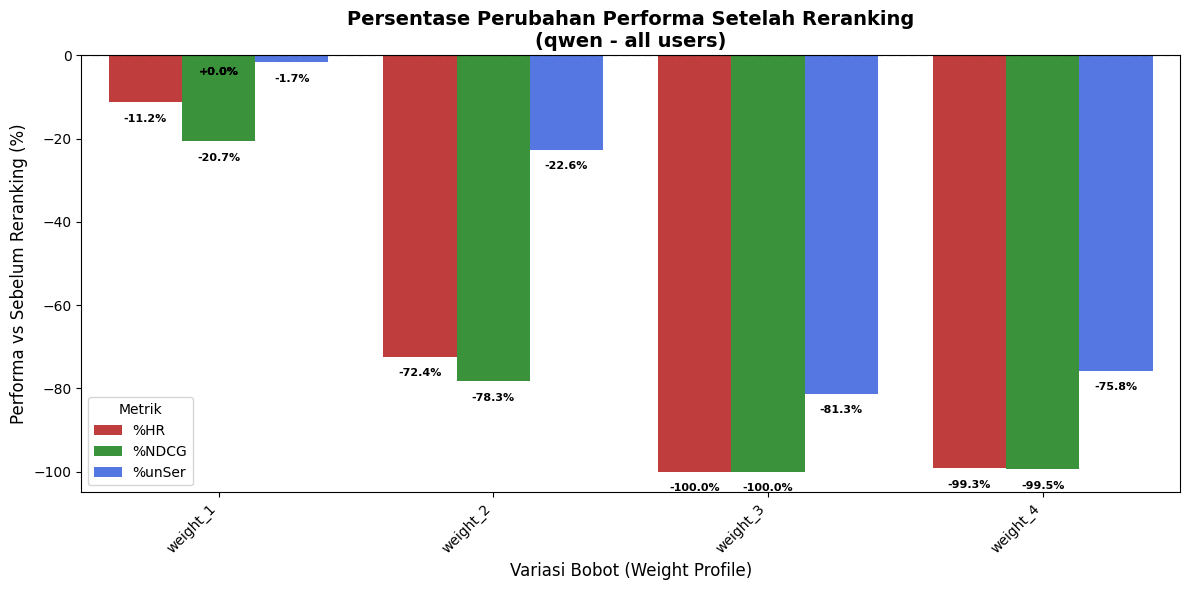

In [69]:
analyze_reranking_impact(df_master, target_model='qwen')

=== ANALISIS DAMPAK RERANKING ===
Model: gemini | Skenario: ALL | Top-10


Weight Profile,HR,NDCG,unSer,%HR,%NDCG,%unSer
None,0.2022,0.1329,0.7229,+0.00%,+0.00%,+0.00%
weight_1,0.1548,0.0920,0.7205,-23.44%,-30.78%,-0.32%
weight_2,0.0411,0.0246,0.6063,-79.69%,-81.52%,-16.12%
weight_3,0.0032,0.0011,0.2570,-98.44%,-99.20%,-64.44%
weight_4,0.0032,0.0021,0.2919,-98.44%,-98.45%,-59.62%


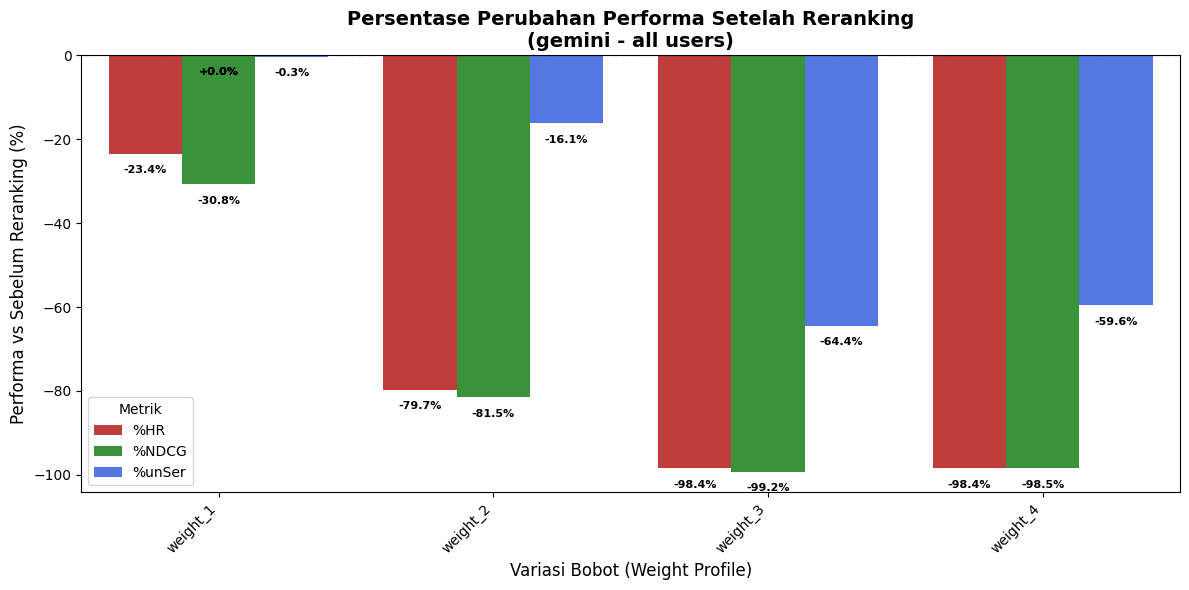

In [72]:
analyze_reranking_impact(df_master, target_model='gemini')

=== ANALISIS DAMPAK RERANKING ===
Model: bert | Skenario: ALL | Top-10


Weight Profile,HR,NDCG,unSer,%HR,%NDCG,%unSer
None,0.0174,0.0094,0.8702,+0.00%,+0.00%,+0.00%
weight_1,0.0032,0.0012,0.8696,-81.82%,-87.00%,-0.08%
weight_2,0.0000,0.0000,0.8612,-100.00%,-100.00%,-1.04%
weight_3,0.0032,0.0011,0.8103,-81.82%,-88.80%,-6.89%
weight_4,0.0032,0.0011,0.8188,-81.82%,-88.80%,-5.91%


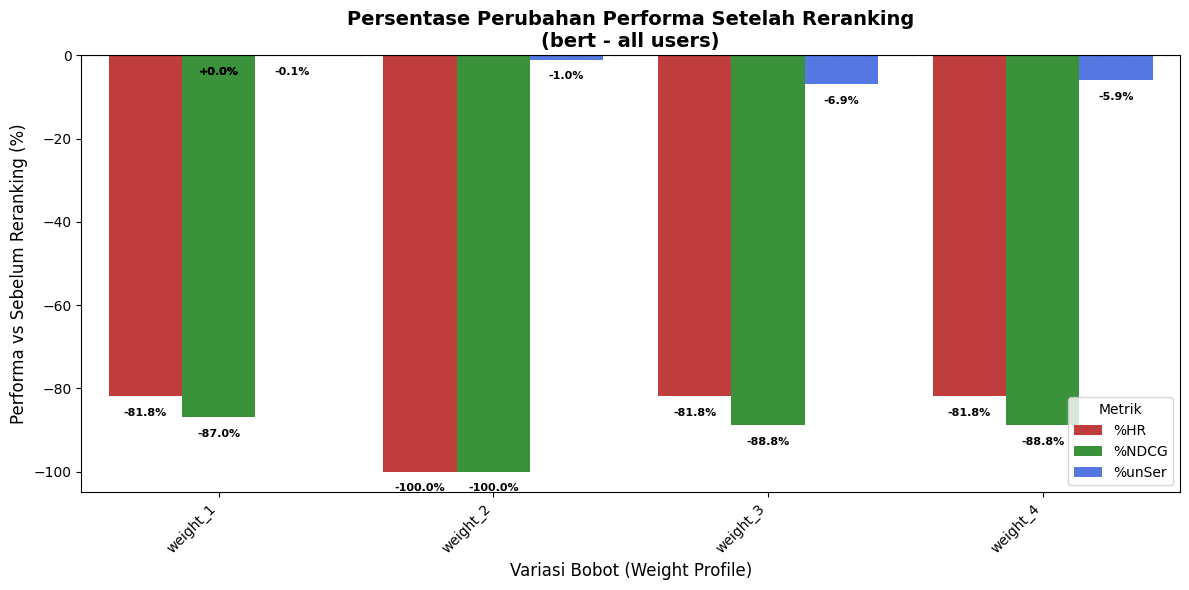

In [76]:
analyze_reranking_impact(df_master, target_model='bert')

=== ANALISIS DAMPAK RERANKING ===
Model: openai | Skenario: ALL | Top-10


Weight Profile,HR,NDCG,unSer,%HR,%NDCG,%unSer
None,0.1927,0.1355,0.6064,+0.00%,+0.00%,+0.00%
weight_1,0.1596,0.1031,0.5990,-17.21%,-23.95%,-1.22%
weight_2,0.0427,0.0255,0.4590,-77.87%,-81.18%,-24.31%
weight_3,0.0016,0.0005,0.1258,-99.18%,-99.63%,-79.26%
weight_4,0.0016,0.0006,0.1572,-99.18%,-99.55%,-74.07%


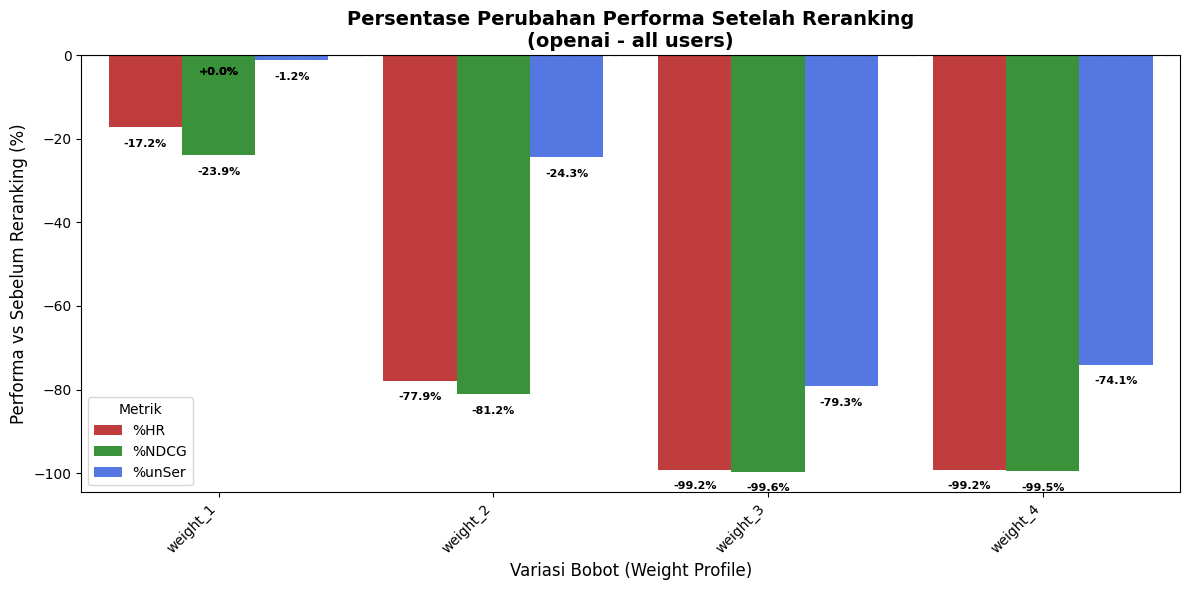

In [75]:
analyze_reranking_impact(df_master, target_model='openai')

=== ANALISIS DAMPAK RERANKING ===
Model: w2v | Skenario: ALL | Top-10


Weight Profile,HR,NDCG,unSer,%HR,%NDCG,%unSer
None,0.0190,0.0069,0.8900,+0.00%,+0.00%,+0.00%
weight_1,0.0047,0.0017,0.8889,-75.00%,-75.41%,-0.12%
weight_2,0.0032,0.0015,0.8779,-83.33%,-79.01%,-1.36%
weight_3,0.0032,0.0011,0.7964,-83.33%,-84.31%,-10.52%
weight_4,0.0047,0.0015,0.8045,-75.00%,-77.99%,-9.61%


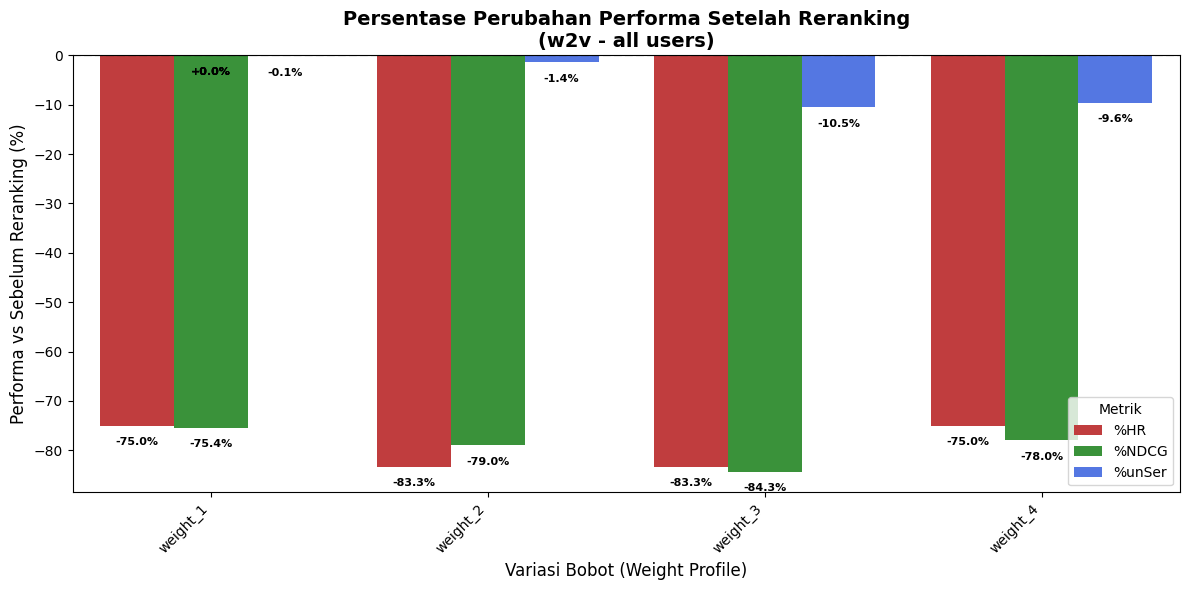

In [74]:
analyze_reranking_impact(df_master, target_model='w2v')

=== ANALISIS DAMPAK RERANKING ===
Model: qwen | Skenario: WARM | Top-10


Weight Profile,HR,NDCG,unSer,%HR,%NDCG,%unSer
None,0.2759,0.1935,0.6175,+0.00%,+0.00%,+0.00%
weight_1,0.2469,0.1540,0.6072,-10.53%,-20.42%,-1.66%
weight_2,0.0768,0.0422,0.4767,-72.18%,-78.19%,-22.79%
weight_3,0.0000,0.0000,0.1170,-100.00%,-100.00%,-81.05%
weight_4,0.0021,0.0010,0.1471,-99.25%,-99.46%,-76.18%


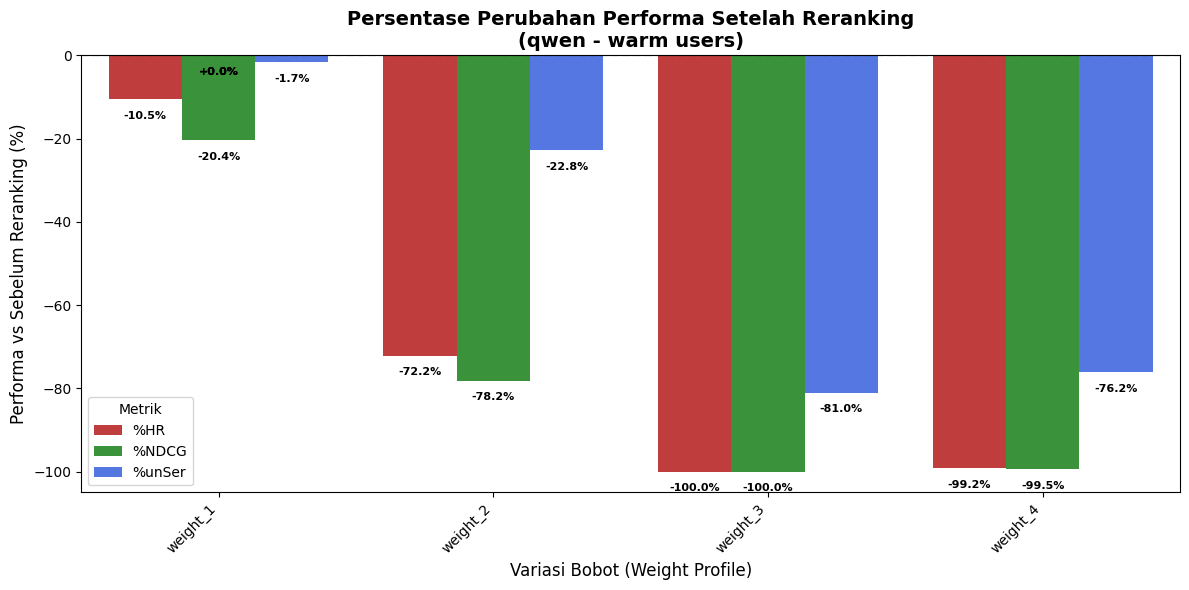

In [71]:
analyze_reranking_impact(df_master, target_model='qwen', user_type='warm')